# Warehouse Storage Distance Optimization — Pipeline

## Problem Statement
Given a warehouse with **4 storage floors + 1 ground floor** (receiving), find the **shortest path** from the chariot elevator exit on each floor to every available storage slot, so we can assign incoming products to the optimal (nearest) slot.

### Floor Matrix Encoding
| Value | Meaning |
|-------|---------|
| `0`   | Walkable empty space (aisle) |
| `1`   | Storage slot (walkable **only if it has remaining capacity**, otherwise treated as obstacle) |
| `2`   | Elevator (person elevator — not used for floor-to-floor freight) |
| `3`   | Chariot elevator (freight — the **entry/exit point** on each floor) |
| `4`   | Obstacle (wall, pillar, etc.) |

### Cost Model (all in meters / seconds as appropriate)
- **Unloading at ground floor**: fixed time *(constant, excluded from optimization)*
- **Ground floor → chariot elevator**: fixed time *(constant, excluded from optimization)*
- **Ascending per floor**: fixed time per floor *(linear, included)*
- **Navigation on a floor**: **BFS/Dijkstra shortest path** from chariot elevator cell(s) to target storage slot *(variable, the main thing to optimize)*
- **Cell-to-cell distance**: 1 m (4-directional: up/down/left/right, no diagonals)

---

## Pipeline Steps

## Step 1 — Load & Build Floor Matrices

**Goal**: Construct one 2D NumPy matrix per floor (floors 1–4).

**What to do**:
1. Load your emplacement/layout data (from DB, CSV, or the JSON outputs of `01_storagePrep`).
2. For each floor, determine the grid dimensions (rows × columns).
3. Fill each cell with its type code: `0` (aisle), `1` (storage slot), `2` (elevator), `3` (chariot elevator), `4` (obstacle).
4. Store the 4 matrices in a dict like `floor_matrices = {1: matrix_f1, 2: matrix_f2, ...}`.

**Why**: This is the foundational data structure. Everything downstream (pathfinding, distance computation) operates on these matrices.

In [27]:
import numpy as np
import re

In [28]:
csv_path = "Book1.csv"   # <-- your layout file
csv_path_2 = "Book2.csv"
raw_matrix = np.genfromtxt(csv_path, delimiter=",", dtype=str)
raw_matrix_2 = np.genfromtxt(csv_path_2, delimiter=",", dtype=str)


In [29]:
print(raw_matrix.shape)

(30, 45)


In [30]:
rows, cols = raw_matrix.shape


In [31]:
rows_2, cols_2 = raw_matrix_2.shape


In [32]:
type_matrix = np.zeros((rows, cols), dtype=int)
slot_matrix = np.empty((rows, cols), dtype=object)

In [33]:
type_matrix_2 = np.zeros((rows_2, cols_2), dtype=int)
slot_matrix_2 = np.empty((rows_2, cols_2), dtype=object)

In [34]:
cell = raw_matrix[1, 1].strip()
print(f"Cell content: '{cell}'")
cell_type = int(cell[-1])
print(cell_type)

Cell content: '(B7)1'
1


In [35]:
match = re.search(r"\((.*?)\)", cell)
print(match)

<re.Match object; span=(0, 4), match='(B7)'>


In [36]:
for i in range(rows):
    for j in range(cols):
        cell = raw_matrix[i, j].strip()
        
        # Skip empty cells
        if not cell:
            type_matrix[i, j] = 0  # treat as aisle
            slot_matrix[i, j] = None
            continue
        
        # Extract numeric type (LAST character)
        cell_type = int(cell[-1])
        type_matrix[i, j] = cell_type
        
        # If storage slot (type == 1), extract slot ID inside ()
        if cell_type == 1:
            match = re.search(r"\((.*?)\)", cell)
            if match:
                slot_matrix[i, j] = match.group(1)
            else:
                slot_matrix[i, j] = None
        else:
            slot_matrix[i, j] = None



In [37]:
for i in range(rows_2):
    for j in range(cols_2):
        cell = raw_matrix_2[i, j].strip()
        
        # Skip empty cells
        if not cell:
            type_matrix_2[i, j] = 0  # treat as aisle
            slot_matrix_2[i, j] = None
            continue
        
        # Extract numeric type (LAST character) - check if it's a digit
        if cell[-1].isdigit():
            cell_type = int(cell[-1])
            type_matrix_2[i, j] = cell_type
            
            # If storage slot (type == 1), extract slot ID inside ()
            if cell_type == 1:
                match = re.search(r"\((.*?)\)", cell)
                if match:
                    slot_matrix_2[i, j] = match.group(1)
                else:
                    slot_matrix_2[i, j] = None
            else:
                slot_matrix_2[i, j] = None
        else:
            # If no digit at end, treat as aisle or extract type differently
            type_matrix_2[i, j] = 0
            slot_matrix_2[i, j] = None



In [38]:
print("✓ Parsed matrix successfully")
print(f"Shape: {type_matrix_2.shape}")
print(f"\nSample type matrix (first 5x5):\n{type_matrix_2[:10, :10]}")
print(f"\nSample slot matrix (first 5x5):\n{slot_matrix_2[:10, :10]}")

✓ Parsed matrix successfully
Shape: (30, 44)

Sample type matrix (first 5x5):
[[1 1 1 1 1 1 1 0 0 1]
 [1 4 0 0 0 0 4 0 0 1]
 [1 0 0 0 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 0 0 1]
 [1 2 2 2 2 2 0 0 0 1]
 [1 2 2 2 2 2 0 0 0 1]
 [1 2 2 2 2 2 0 0 0 1]
 [1 2 2 2 2 2 0 0 0 1]
 [0 0 0 0 0 0 0 0 0 0]]

Sample slot matrix (first 5x5):
[['B6' 'B5' 'B5' 'B5' 'B5' 'B5' 'B5' None None 'B4']
 ['B6' None None None None None None None None 'B4']
 ['B6' None None None None None None None None 'B4']
 ['B6' None None None None None None None None 'B4']
 ['B6' None None None None None None None None 'B4']
 ['B6' None None None None None None None None 'B4']
 ['B6' None None None None None None None None 'B4']
 ['B6' None None None None None None None None 'B4']
 ['B6' None None None None None None None None 'B4']
 [None None None None None None None None None None]]


In [39]:
floor_matrices = {
    1: {"type": type_matrix.copy(), "slots": slot_matrix.copy()},
    2: {"type": type_matrix.copy(), "slots": slot_matrix.copy()},
    3: {"type": type_matrix_2.copy(), "slots": slot_matrix_2.copy()},
    4: {"type": type_matrix_2.copy(), "slots": slot_matrix_2.copy()},
}

# -------------------------------------------------
# Example check
# -------------------------------------------------

print("Floor 1 Type Matrix:")
print(floor_matrices[3]["type"])

print("\nFloor 1 Slot Matrix:")
print(floor_matrices[3]["slots"])


Floor 1 Type Matrix:
[[1 1 1 ... 1 0 0]
 [1 4 0 ... 1 0 0]
 [1 0 0 ... 1 0 0]
 ...
 [1 0 1 ... 0 0 0]
 [1 0 1 ... 0 0 0]
 [1 4 1 ... 0 0 0]]

Floor 1 Slot Matrix:
[['B6' 'B5' 'B5' ... 'A1' None None]
 ['B6' None None ... 'A1' None None]
 ['B6' None None ... 'A1' None None]
 ...
 ['E17' None 'E16' ... None None None]
 ['E17' None 'E16' ... None None None]
 ['E17' None 'E16' ... None None None]]


## Step 2 — Build a Slot Metadata Lookup

**Goal**: Create a mapping from each storage slot's **(floor, row, col)** position to its metadata (emplacement ID, current volume used, max capacity, remaining capacity).

**What to do**:
1. Load the enriched inventory & emplacement volumes from `01_storagePrep` outputs.
2. For each storage cell in each floor matrix, link it to its emplacement ID, current fill level, and max capacity.
3. Store as a dict: `slot_meta[(floor, r, c)] = {"id": "EMP-123", "used_m3": 5, "max_m3": 10, "remaining_m3": 5}`.

**Why**: You need to know *which slots have remaining capacity* (can receive products + are walkable) vs. *which are full* (act as obstacles for pathfinding).

In [40]:
import pandas as pd
import json

In [41]:
# Step 1: Load emplacements.csv and filter for RESERVE type only
emplacements_df = pd.read_csv("emplacements.csv")
reserve_emplacements = emplacements_df[emplacements_df['type_emplacement'] == 'RESERVE'].copy()

print(f"✓ Loaded {len(reserve_emplacements)} RESERVE emplacements from CSV")
print(f"\nSample entries:")
print(reserve_emplacements[['id_emplacement', 'code_emplacement', 'zone']].head(10))

✓ Loaded 178 RESERVE emplacements from CSV

Sample entries:
     id_emplacement code_emplacement    zone
660            1331        B07-N(-1)  B07-SS
661             398        B07-N1-A1  B07-N1
662             400        B07-N1-A2  B07-N1
663             402        B07-N1-A3  B07-N1
664             403        B07-N1-A4  B07-N1
665             404        B07-N1-A5  B07-N1
666             405        B07-N1-A6  B07-N1
667             406        B07-N1-A7  B07-N1
668             407        B07-N1-A8  B07-N1
669             408        B07-N1-B1  B07-N1


In [42]:
# Step 2: Load available slots from JSON
# (Create placeholder if file doesn't exist yet)
available_slots_json_path = "emplacement_available_slots.json"

try:
    with open(available_slots_json_path, 'r') as f:
        available_slots = json.load(f)
    print(f"✓ Loaded available slots for {len(available_slots)} emplacements")
    print(f"\nSample entries:")
    for i, (emp_id, avail) in enumerate(list(available_slots.items())[:5]):
        print(f"  {emp_id}: {avail} m³ available")
except FileNotFoundError:
    print(f"⚠ File '{available_slots_json_path}' not found - using placeholder")
    available_slots = {}

✓ Loaded available slots for 175 emplacements

Sample entries:
  1358: 9954.12 m³ available
  411: 7904.68 m³ available
  1389: 6287.4 m³ available
  1390: 9434.2 m³ available
  1326: 9766.9 m³ available


In [43]:
# Step 3: Build lookup dict from code_emplacement to (id_emplacement, available_slots)
code_to_metadata = {}

for _, row in reserve_emplacements.iterrows():
    code = row['code_emplacement']
    emp_id = row['id_emplacement']
    
    # Get available slots from JSON
    avail = available_slots.get(str(emp_id), 0)  # default 0 if not found
    
    code_to_metadata[code] = {
        'id_emplacement': emp_id,
        'available_m3': avail
    }

print(f"✓ Built lookup for {len(code_to_metadata)} emplacement codes")
print(f"\nSample lookups:")
for i, (code, meta) in enumerate(list(code_to_metadata.items())[:5]):
    print(f"  {code} -> ID={meta['id_emplacement']}, available={meta['available_m3']} m³")

✓ Built lookup for 178 emplacement codes

Sample lookups:
  B07-N(-1) -> ID=1331, available=9782.942 m³
  B07-N1-A1 -> ID=398, available=7230.11 m³
  B07-N1-A2 -> ID=400, available=9813.15 m³
  B07-N1-A3 -> ID=402, available=6921.17 m³
  B07-N1-A4 -> ID=403, available=9667.0 m³


In [44]:
print(floor_matrices[2]["slots"][0][0])

None


In [45]:
MAX_CAPACITY_M3 = 10000

In [46]:
# Helper function to calculate storage priority based on position
# Lower priority = fill first (to keep walkways clear)
def calculate_storage_priority(floor, slot_id, row, col):
    """
    Calculate storage priority for a slot.
    Lower number = fill first (edges/back of room)
    Higher number = fill last (keep for walkways)
    """
    # Extract letter and number from slot_id (e.g., "B7" -> letter="B", num=7)
    import re
    match = re.match(r'([A-Z]+)(\d+)', slot_id)
    if not match:
        return 999  # Unknown pattern, deprioritize
    
    letter = match.group(1)
    num = int(match.group(2))
    
    # Floor 1 & 2: Same layout
    if floor in [1, 2]:
        if letter in ['A', 'B']:
            # Top of room: prioritize higher numbers first (back of room)
            # B7/A8 = priority 0, B1/A1 = priority 18
            return 20 - num
        elif letter == 'E':
            # Bottom of room: prioritize higher numbers first (back of room)
            # E18 = priority 0, E1 = priority 17
            return 20 - num
        elif letter in ['C', 'D']:
            # Middle: start from middle (around 5) and expand
            # Priority increases as we move away from middle
            middle = 5
            return abs(num - middle)
        else:
            return 50  # Unknown letter
    
    # Floor 3 & 4: Check based on row position (top/bottom of matrix)
    elif floor in [3, 4]:
        # Rows near 0 (top) or near max (bottom) should be filled first
        # Middle rows should be kept clear for walking
        matrix_height = floor_matrices[floor]["slots"].shape[0]
        middle_row = matrix_height // 2
        
        # Distance from edge (top or bottom)
        dist_from_top = row
        dist_from_bottom = matrix_height - row - 1
        dist_from_edge = min(dist_from_top, dist_from_bottom)
        
        # Priority increases as we move toward center (keep center clear)
        return dist_from_edge * 10 + (20 - num)
    
    return 100  # Default

print("✓ Storage priority function defined")

✓ Storage priority function defined


---

## 🎯 Smart Storage Strategy Implementation

**Key Enhancement**: Storage slots are now prioritized to **maximize walkability** by filling edges/back slots first, keeping central pathways clear for efficient movement.

### Updates Made:

**1. Storage Priority System**
- Added `calculate_storage_priority(floor, slot_id, row, col)` function
- Assigns priority score (lower = fill first) based on:
  - Floors 1 & 2: Letter zones (A/B at top, E at bottom, C/D in middle)
  - Floors 3 & 4: Distance from matrix edges
- Strategy: Fill back/edge slots first → keep walkways open longer

**2. Enhanced Slot Metadata**  
`slot_meta` now includes:
- `total_capacity_m3`: Fixed capacity (divided among cells sharing same emplacement)
- `used_m3`: Currently stored volume (updated on assignment)
- `remaining_m3`: Available capacity (`total_capacity - used`)
- `storage_priority`: Fill order (lower = fill first)

**3. Improved Slot Ranking**  
`ranked_slots` now sorted by:
- **Primary**: `storage_priority` (fill edges first)
- **Secondary**: `total_cost` (minimize travel)

**4. Updated Assignment Function**  
`find_best_slot(volume, update_capacity=False)`:
- Checks CURRENT `remaining_m3` from `slot_meta`
- Prioritizes edge/back slots automatically
- Optional: Actually updates capacity tracking with `update_capacity=True`

---


In [ ]:
# Step 4: Build slot_meta[(floor, r, c)] with actual data

# FIRST PASS: Count how many cells map to each emplacement code
emplacement_cell_count = {}

for floor in [1, 2, 3, 4]:
    slot_matrix_floor = floor_matrices[floor]["slots"]
    rows, cols = slot_matrix_floor.shape
    
    for r in range(rows):
        for c in range(cols):
            slot_id = slot_matrix_floor[r, c]
            
            if slot_id is not None:
                expected_code = f"B07-N{floor}-{slot_id}"
                emplacement_cell_count[expected_code] = emplacement_cell_count.get(expected_code, 0) + 1

print("Step 4a: Counted cells per emplacement code")
print(f"  Unique emplacement codes: {len(emplacement_cell_count)}")
print(f"  Example counts: {list(emplacement_cell_count.items())[:5]}")

# SECOND PASS: Build slot_meta with divided capacity + storage priority + usage tracking
slot_meta = {}

total_storage_cells = 0
matched_cells = 0
unmatched_cells = 0
unmatched_id_counter = 2000  # Start IDs for unmatched slots from 2000

for floor in [1, 2, 3, 4]:
    slot_matrix_floor = floor_matrices[floor]["slots"]
    rows, cols = slot_matrix_floor.shape
    
    for r in range(rows):
        for c in range(cols):
            slot_id = slot_matrix_floor[r, c]
            
            # Only process if this is a storage cell (not None)
            if slot_id is not None:
                total_storage_cells += 1
                
                # Build expected code: B07-N{floor}-{slot_id}
                expected_code = f"B07-N{floor}-{slot_id}"
                
                # Get the count of cells sharing this emplacement code
                cell_count = emplacement_cell_count[expected_code]
                
                # Calculate storage priority for this slot
                priority = calculate_storage_priority(floor, slot_id, r, c)
                
                # Look up in code_to_metadata
                if expected_code in code_to_metadata:
                    matched_cells += 1
                    meta = code_to_metadata[expected_code]
                    
                    # Total capacity per cell = MAX divided by cells sharing this emplacement
                    total_per_cell = MAX_CAPACITY_M3 / cell_count
                    # Remaining per cell = available from JSON divided by cells
                    remaining_per_cell = meta['available_m3'] / cell_count
                    # Used = total - remaining (what's already stored)
                    used_per_cell = total_per_cell - remaining_per_cell
                    
                    slot_meta[(floor, r, c)] = {
                        'slot_id': slot_id,
                        'emplacement_code': expected_code,
                        'id_emplacement': meta['id_emplacement'],
                        'total_capacity_m3': total_per_cell,
                        'used_m3': used_per_cell,
                        'remaining_m3': remaining_per_cell,
                    # For unmatched: divide MAX capacity by cell count, 0 used
                    total_per_cell = MAX_CAPACITY_M3 / cell_count
                else:
                    unmatched_cells += 1
                    # For unmatched: divide MAX capacity by cell count
                    divided_capacity = MAX_CAPACITY_M3 / cell_count
                    
                        'total_capacity_m3': total_per_cell,
                        'used_m3': 0.0,  # Unmatched = empty
                        'remaining_m3': total_per_cell,  # All available
                        'id_emplacement': unmatched_id_counter,
                        'total_capacity_m3': divided_capacity,
                        'used_m3': 0.0,  # Initialize as empty
                        'remaining_m3': divided_capacity,  # Initially all available
                        'storage_priority': priority  # Lower = fill first
                    }
                    unmatched_id_counter += 1

print(f"\n✓ Processed {total_storage_cells} storage cells")
print(f"  - Matched: {matched_cells}")
print(f"  - Unmatched: {unmatched_cells}")
print(f"  - Generated IDs: 2000 to {unmatched_id_counter - 1}")
print(f"\nslot_meta now has {len(slot_meta)} entries with:")
print(f"  - total_capacity_m3 (divided among cells)")

print(f"  - used_m3 (tracks storage)")

print(f"  - remaining_m3 (capacity - used)")print(f"  - storage_priority (lower = fill first)")

Step 4a: Counted cells per emplacement code
  Unique emplacement codes: 210
  Example counts: [('B07-N1-B7', 9), ('B07-N1-B5', 9), ('B07-N1-B4', 18), ('B07-N1-B3', 9), ('B07-N1-B2', 18)]

✓ Processed 2270 storage cells
  - Matched: 1788
  - Unmatched: 482
  - Generated IDs: 2000 to 2481

slot_meta now has 2270 entries with:
  - total_capacity_m3 (divided among cells)
  - used_m3 (tracks storage)
  - remaining_m3 (capacity - used)
  - storage_priority (lower = fill first)


In [48]:
# Export unmatched cells to JSON for inspection
import json

unmatched_data = []

for key, meta in slot_meta.items():
    # Check if this is an unmatched cell (id_emplacement is None)
    if meta['id_emplacement'] is None:
        floor, r, c = key
        unmatched_data.append({
            "floor": floor,
            "row": r,
            "col": c,
            "slot_id": meta['slot_id'],
            "expected_emplacement_code": meta['emplacement_code'],
            "reason": "Code not found in emplacements.csv or JSON"
        })

# Save to JSON file
output_file = "unmatched_slots.json"
with open(output_file, 'w') as f:
    json.dump(unmatched_data, f, indent=2)

print(f"✓ Exported {len(unmatched_data)} unmatched slots to '{output_file}'")
print(f"\nFirst 5 unmatched examples:")
for i, item in enumerate(unmatched_data[:5]):
    print(f"  {i+1}. Floor {item['floor']}, ({item['row']},{item['col']}): "
          f"Slot '{item['slot_id']}' → Expected code: '{item['expected_emplacement_code']}'")

✓ Exported 0 unmatched slots to 'unmatched_slots.json'

First 5 unmatched examples:


In [49]:
print(slot_meta)

{(1, 0, 1): {'slot_id': 'B7', 'emplacement_code': 'B07-N1-B7', 'id_emplacement': 412, 'total_capacity_m3': 1111.111111111111, 'used_m3': 0.0, 'remaining_m3': 1111.111111111111, 'storage_priority': 13}, (1, 0, 8): {'slot_id': 'B5', 'emplacement_code': 'B07-N1-B5', 'id_emplacement': 878, 'total_capacity_m3': 1100.1944444444443, 'used_m3': 0.0, 'remaining_m3': 1100.1944444444443, 'storage_priority': 15}, (1, 0, 10): {'slot_id': 'B4', 'emplacement_code': 'B07-N1-B4', 'id_emplacement': 1352, 'total_capacity_m3': 554.2325555555556, 'used_m3': 0.0, 'remaining_m3': 554.2325555555556, 'storage_priority': 16}, (1, 0, 11): {'slot_id': 'B4', 'emplacement_code': 'B07-N1-B4', 'id_emplacement': 1352, 'total_capacity_m3': 554.2325555555556, 'used_m3': 0.0, 'remaining_m3': 554.2325555555556, 'storage_priority': 16}, (1, 0, 13): {'slot_id': 'B3', 'emplacement_code': 'B07-N1-B3', 'id_emplacement': 410, 'total_capacity_m3': 1111.111111111111, 'used_m3': 0.0, 'remaining_m3': 1111.111111111111, 'storage_pri

In [50]:
# Step 5: Display sample entries from slot_meta
print("Sample slot_meta entries:")
print("=" * 80)

for i, (key, meta) in enumerate(list(slot_meta.items())[:30]):
    floor, r, c = key
    print(f"Floor {floor}, Position ({r},{c}):")
    print(f"  Slot ID: {meta['slot_id']}")
    print(f"  Code: {meta['emplacement_code']}")
    print(f"  ID: {meta['id_emplacement']}")
    print(f"  Total Capacity: {meta['total_capacity_m3']:.2f} m³")
    print(f"  Used: {meta['used_m3']:.2f} m³")
    print(f"  Remaining: {meta['remaining_m3']:.2f} m³")
    print(f"  Storage Priority: {meta['storage_priority']}")
    print()

Sample slot_meta entries:
Floor 1, Position (0,1):
  Slot ID: B7
  Code: B07-N1-B7
  ID: 412
  Total Capacity: 1111.11 m³
  Used: 0.00 m³
  Remaining: 1111.11 m³
  Storage Priority: 13

Floor 1, Position (0,8):
  Slot ID: B5
  Code: B07-N1-B5
  ID: 878
  Total Capacity: 1100.19 m³
  Used: 0.00 m³
  Remaining: 1100.19 m³
  Storage Priority: 15

Floor 1, Position (0,10):
  Slot ID: B4
  Code: B07-N1-B4
  ID: 1352
  Total Capacity: 554.23 m³
  Used: 0.00 m³
  Remaining: 554.23 m³
  Storage Priority: 16

Floor 1, Position (0,11):
  Slot ID: B4
  Code: B07-N1-B4
  ID: 1352
  Total Capacity: 554.23 m³
  Used: 0.00 m³
  Remaining: 554.23 m³
  Storage Priority: 16

Floor 1, Position (0,13):
  Slot ID: B3
  Code: B07-N1-B3
  ID: 410
  Total Capacity: 1111.11 m³
  Used: 0.00 m³
  Remaining: 1111.11 m³
  Storage Priority: 17

Floor 1, Position (0,15):
  Slot ID: B2
  Code: B07-N1-B2
  ID: 409
  Total Capacity: 528.33 m³
  Used: 0.00 m³
  Remaining: 528.33 m³
  Storage Priority: 18

Floor 1, Posit

In [51]:
# Step 6: Summary statistics per floor
print("=" * 80)
print("SUMMARY PER FLOOR")
print("=" * 80)

for floor in [1, 2, 3, 4]:
    floor_slots = [(k, v) for k, v in slot_meta.items() if k[0] == floor]
    
    total = len(floor_slots)
    matched = sum(1 for k, v in floor_slots if v['id_emplacement'] is not None and v['id_emplacement'] < 2000)
    unmatched = total - matched
    
    # Calculate capacity statistics
    total_capacity = sum(v['total_capacity_m3'] for k, v in floor_slots)
    total_used = sum(v['used_m3'] for k, v in floor_slots)
    total_remaining = sum(v['remaining_m3'] for k, v in floor_slots)
    
    print(f"\nFloor {floor}:")
    print(f"  Storage slots: {total}")
    print(f"  Matched to CSV: {matched}")
    print(f"  Unmatched (generated IDs): {unmatched}")
    print(f"  Total capacity: {total_capacity:.2f} m³")
    print(f"  Used: {total_used:.2f} m³ ({100*total_used/total_capacity:.1f}%)")
    print(f"  Remaining: {total_remaining:.2f} m³ ({100*total_remaining/total_capacity:.1f}%)")


SUMMARY PER FLOOR

Floor 1:
  Storage slots: 617
  Matched to CSV: 617
  Unmatched (generated IDs): 0
  Total capacity: 455990.71 m³
  Used: 0.00 m³ (0.0%)
  Remaining: 455990.71 m³ (100.0%)

Floor 2:
  Storage slots: 617
  Matched to CSV: 617
  Unmatched (generated IDs): 0
  Total capacity: 488340.49 m³
  Used: 0.00 m³ (0.0%)
  Remaining: 488340.49 m³ (100.0%)

Floor 3:
  Storage slots: 518
  Matched to CSV: 248
  Unmatched (generated IDs): 270
  Total capacity: 548658.21 m³
  Used: 0.00 m³ (0.0%)
  Remaining: 548658.21 m³ (100.0%)

Floor 4:
  Storage slots: 518
  Matched to CSV: 306
  Unmatched (generated IDs): 212
  Total capacity: 549139.99 m³
  Used: 0.00 m³ (0.0%)
  Remaining: 549139.99 m³ (100.0%)


In [58]:
# QUICK TEST: Assign one product to verify capacity tracking works
print("\n" + "=" * 80)
print("🧪 QUICK TEST: Assign one product")
print("=" * 80)

test_volume = 500  # m³
print(f"\n📦 Assigning test product ({test_volume} m³)...\n")

result = find_best_slot(test_volume, update_capacity=True)

if result:
    print(f"✓ Product assigned successfully!")
    print(f"  Slot: {result['emplacement_code']}")
    print(f"  Floor: {result['floor']}, Position: {result['position']}")
    print(f"  Priority: {result['storage_priority']} (lower = filled first)")
    print(f"  Capacity before: {result['remaining_capacity']:.2f} m³")
    print(f"  Capacity after: {result['capacity_after_storage']:.2f} m³")
    
    # Verify the slot was actually updated
    slot_key = (result['floor'], result['position'][0], result['position'][1])
    updated_slot = slot_meta[slot_key]
    print(f"\n✓ Verification: Slot's used_m3 = {updated_slot['used_m3']:.2f} m³")
    
    # Show updated totals
    total_used_now = sum(s['used_m3'] for s in slot_meta.values())
    total_capacity = sum(s['total_capacity_m3'] for s in slot_meta.values())
    print(f"✓ Total warehouse used: {total_used_now:.2f} m³ ({100*total_used_now/total_capacity:.4f}%)")
else:
    print("❌ No suitable slot found!")



🧪 QUICK TEST: Assign one product

📦 Assigning test product (500 m³)...

❌ No suitable slot found!


In [59]:
# Search for specific slot: B07-N3-E16 on Floor 3
target_code = "B07-N3-E16"
target_floor = 3

print(f"Searching for slot: {target_code} on Floor {target_floor}")
print("=" * 80)

found = False
for (floor, r, c), meta in slot_meta.items():
    if floor == target_floor and meta['emplacement_code'] == target_code:
        found = True
        print(f"\n✓ FOUND!")
        print(f"  Position: Floor {floor}, Row {r}, Column {c}")
        print(f"  Slot ID: {meta['slot_id']}")
        print(f"  Emplacement Code: {meta['emplacement_code']}")
        print(f"  ID Emplacement: {meta['id_emplacement']}")
        print(f"  Total Capacity: {meta['total_capacity_m3']:.2f} m³")
        print(f"  Used: {meta['used_m3']:.2f} m³")
        print(f"  Remaining: {meta['remaining_m3']:.2f} m³")
        print(f"  Storage Priority: {meta['storage_priority']}")
        break

if not found:
    print(f"\n✗ NOT FOUND: {target_code} on Floor {target_floor}")
    print("\nSearching all floors for this code...")
    for (floor, r, c), meta in slot_meta.items():
        if meta['emplacement_code'] == target_code:
            print(f"  Found on Floor {floor}, Row {r}, Column {c}")
            print(f"    ID Emplacement: {meta['id_emplacement']}")
            print(f"    Remaining: {meta['remaining_m3']:.2f} m³")


Searching for slot: B07-N3-E16 on Floor 3

✓ FOUND!
  Position: Floor 3, Row 26, Column 2
  Slot ID: E16
  Emplacement Code: B07-N3-E16
  ID Emplacement: 2213
  Total Capacity: 1111.11 m³
  Used: 0.00 m³
  Remaining: 1111.11 m³
  Storage Priority: 34


In [60]:
# Helper function to look up slot info
def get_slot_info(floor, row, col):
    """Get metadata for a specific slot position"""
    key = (floor, row, col)
    return slot_meta.get(key, None)

# Example usage
print("\nExample slot lookup:")
example_key = list(slot_meta.keys())[0] if slot_meta else None
if example_key:
    floor, r, c = example_key
    info = get_slot_info(floor, r, c)
    print(f"get_slot_info({floor}, {r}, {c}) =")
    print(f"  {info}")


Example slot lookup:
get_slot_info(1, 0, 1) =
  {'slot_id': 'B7', 'emplacement_code': 'B07-N1-B7', 'id_emplacement': 412, 'total_capacity_m3': 1111.111111111111, 'used_m3': 0.0, 'remaining_m3': 1111.111111111111, 'storage_priority': 13}


## Step 3 — Build the Walkability Grid (per floor)

**Goal**: For each floor, generate a **boolean walkability matrix** that tells the pathfinding algorithm which cells it can traverse.

**What to do**:
1. Start from the floor matrix.
2. A cell is **walkable** if:
   - It is `0` (aisle) — always walkable
   - It is `1` (storage slot) **and** `remaining_m3 > 0` — walkable (and a valid drop-off target)
   - It is `3` (chariot elevator) — walkable (it's the start point)
   - It is `2` (elevator) — walkable on-floor (you can walk past it)
3. A cell is **NOT walkable** if:
   - It is `4` (obstacle)
   - It is `1` (storage slot) **and** `remaining_m3 == 0` — full, acts as a wall

4. Store as `walkable[floor] = 2D boolean array`.

**Why**: The pathfinding algorithm (BFS) needs to know which cells it can step into. Full storage slots block movement just like walls.

In [61]:
# Define max capacity for storage slots
MAX_CAPACITY_M3 = 10000.0  # m³

print(f"MAX_CAPACITY_M3 = {MAX_CAPACITY_M3} m³")

MAX_CAPACITY_M3 = 10000.0 m³


In [62]:
print(slot_meta.get((1, 0, 1), None))

{'slot_id': 'B7', 'emplacement_code': 'B07-N1-B7', 'id_emplacement': 412, 'total_capacity_m3': 1111.111111111111, 'used_m3': 0.0, 'remaining_m3': 1111.111111111111, 'storage_priority': 13}


In [63]:
# Build walkability grid for each floor
walkable = {}

for floor in [1, 2, 3, 4]:
    type_matrix_floor = floor_matrices[floor]["type"]
    rows, cols = type_matrix_floor.shape
    
    # Create boolean array (True = walkable, False = blocked)
    walkable_matrix = np.zeros((rows, cols), dtype=bool)
    
    for r in range(rows):
        for c in range(cols):
            cell_type = type_matrix_floor[r, c]
            
            # Check walkability rules
            if cell_type == 0:  # Aisle - always walkable
                walkable_matrix[r, c] = True
                
            elif cell_type == 2:  # Elevator - walkable
                walkable_matrix[r, c] = True
                
            elif cell_type == 3:  # Chariot elevator - walkable
                walkable_matrix[r, c] = True
                
            elif cell_type == 1:  # Storage slot - check capacity
                # Get slot metadata
                slot_info = slot_meta.get((floor, r, c), None)
                
                if slot_info:
                    # Walkable only if remaining capacity equals total (empty slot)
                    if slot_info['remaining_m3'] == slot_info['total_capacity_m3']:
                        walkable_matrix[r, c] = True
                    else:
                        walkable_matrix[r, c] = False
                else:
                    # No metadata - assume not walkable
                    walkable_matrix[r, c] = False
                    
            elif cell_type == 4:  # Obstacle - not walkable
                walkable_matrix[r, c] = False
                
            else:
                # Unknown type - not walkable
                walkable_matrix[r, c] = False
    
    walkable[floor] = walkable_matrix

print(f"✓ Built walkability grids for {len(walkable)} floors")

✓ Built walkability grids for 4 floors


In [64]:
# Display walkability statistics per floor
print("=" * 80)
print("WALKABILITY SUMMARY")
print("=" * 80)

for floor in [1, 2, 3, 4]:
    walkable_matrix = walkable[floor]
    type_matrix_floor = floor_matrices[floor]["type"]
    
    total_cells = walkable_matrix.size
    walkable_cells = np.sum(walkable_matrix)
    blocked_cells = total_cells - walkable_cells
    
    # Count by type
    aisles = np.sum(type_matrix_floor == 0)
    storage = np.sum(type_matrix_floor == 1)
    elevators = np.sum(type_matrix_floor == 2)
    chariots = np.sum(type_matrix_floor == 3)
    obstacles = np.sum(type_matrix_floor == 4)
    
    print(f"\nFloor {floor}:")
    print(f"  Total cells: {total_cells}")
    print(f"  Walkable: {walkable_cells} ({100*walkable_cells/total_cells:.1f}%)")
    print(f"  Blocked: {blocked_cells} ({100*blocked_cells/total_cells:.1f}%)")
    print(f"  Breakdown:")
    print(f"    Aisles (0): {aisles}")
    print(f"    Storage (1): {storage}")
    print(f"    Elevators (2): {elevators}")
    print(f"    Chariots (3): {chariots}")
    print(f"    Obstacles (4): {obstacles}")

WALKABILITY SUMMARY

Floor 1:
  Total cells: 1350
  Walkable: 1321 (97.9%)
  Blocked: 29 (2.1%)
  Breakdown:
    Aisles (0): 659
    Storage (1): 617
    Elevators (2): 15
    Chariots (3): 30
    Obstacles (4): 29

Floor 2:
  Total cells: 1350
  Walkable: 1321 (97.9%)
  Blocked: 29 (2.1%)
  Breakdown:
    Aisles (0): 659
    Storage (1): 617
    Elevators (2): 15
    Chariots (3): 30
    Obstacles (4): 29

Floor 3:
  Total cells: 1320
  Walkable: 1283 (97.2%)
  Blocked: 37 (2.8%)
  Breakdown:
    Aisles (0): 715
    Storage (1): 518
    Elevators (2): 20
    Chariots (3): 30
    Obstacles (4): 37

Floor 4:
  Total cells: 1320
  Walkable: 1283 (97.2%)
  Blocked: 37 (2.8%)
  Breakdown:
    Aisles (0): 715
    Storage (1): 518
    Elevators (2): 20
    Chariots (3): 30
    Obstacles (4): 37


In [65]:
# Visualize a sample of the walkability grid (Floor 1, first 10x10)
print("=" * 80)
print("SAMPLE WALKABILITY GRID - Floor 1 (first 10x10)")
print("=" * 80)
print("Legend: 1 = Walkable, 0 = Blocked")
print()

sample_size = 10
sample_walkable = walkable[1][:sample_size, :sample_size].astype(int)
sample_type = floor_matrices[1]["type"][:sample_size, :sample_size]

print("Walkability grid:")
print(sample_walkable)
print()
print("Type grid (for reference):")
print(sample_type)

SAMPLE WALKABILITY GRID - Floor 1 (first 10x10)
Legend: 1 = Walkable, 0 = Blocked

Walkability grid:
[[1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1 1 1 1]]

Type grid (for reference):
[[0 1 0 0 0 0 0 0 1 0]
 [0 1 1 1 1 1 1 0 1 0]
 [0 1 0 0 0 0 0 0 1 0]
 [0 1 0 0 0 0 0 0 1 0]
 [0 1 0 0 0 0 0 0 1 0]
 [0 1 0 0 0 0 0 0 1 0]
 [0 1 2 2 2 2 2 0 1 0]
 [0 1 2 2 2 2 2 0 1 0]
 [0 1 2 2 2 2 2 0 1 0]
 [0 0 0 0 0 0 0 0 0 0]]


In [66]:
# Helper function to check if a position is walkable
def is_walkable(floor, row, col):
    """Check if a specific position is walkable"""
    if floor not in walkable:
        return False
    
    walkable_matrix = walkable[floor]
    rows, cols = walkable_matrix.shape
    
    if 0 <= row < rows and 0 <= col < cols:
        return walkable_matrix[row, col]
    else:
        return False

# Example usage
print("Example walkability checks:")
print(f"  Floor 1, pos (0,0): {is_walkable(1, 0, 0)}")
print(f"  Floor 1, pos (5,5): {is_walkable(1, 5, 5)}")
print(f"  Floor 2, pos (3,3): {is_walkable(2, 3, 3)}")

Example walkability checks:
  Floor 1, pos (0,0): True
  Floor 1, pos (5,5): True
  Floor 2, pos (3,3): True


## Step 4 — Identify Source & Target Cells

**Goal**: For each floor, find the **chariot elevator cells** (source/entry points) and all **available storage slots** (targets).

**What to do**:
1. Scan each floor matrix for cells with value `3` → these are the **source(s)** on that floor (there may be more than one chariot elevator per floor).
2. Scan for cells with value `1` that have `remaining_m3 > 0` → these are the **target candidates**.
3. Store as:
   - `chariot_positions[floor] = [(r1, c1), (r2, c2), ...]`
   - `available_targets[floor] = [(r, c, emplacement_id, remaining_m3), ...]`

**Why**: BFS will run **from** each chariot elevator position **to** all reachable cells. You then read off distances to each available target.

In [67]:
# Step 1: Find chariot elevator positions (source cells)
chariot_positions = {}

for floor in [1, 2, 3, 4]:
    type_matrix_floor = floor_matrices[floor]["type"]
    rows, cols = type_matrix_floor.shape
    
    positions = []
    
    for r in range(rows):
        for c in range(cols):
            if type_matrix_floor[r, c] == 3:  # Chariot elevator
                positions.append((r, c))
    
    chariot_positions[floor] = positions

print("✓ Found chariot elevator positions")
print("=" * 80)
for floor, positions in chariot_positions.items():
    print(f"Floor {floor}: {len(positions)} chariot elevator(s) at {positions}")

✓ Found chariot elevator positions
Floor 1: 30 chariot elevator(s) at [(4, 29), (4, 30), (4, 31), (4, 32), (4, 33), (4, 34), (5, 29), (5, 30), (5, 31), (5, 32), (5, 33), (5, 34), (6, 29), (6, 30), (6, 31), (6, 32), (6, 33), (6, 34), (7, 29), (7, 30), (7, 31), (7, 32), (7, 33), (7, 34), (8, 29), (8, 30), (8, 31), (8, 32), (8, 33), (8, 34)]
Floor 2: 30 chariot elevator(s) at [(4, 29), (4, 30), (4, 31), (4, 32), (4, 33), (4, 34), (5, 29), (5, 30), (5, 31), (5, 32), (5, 33), (5, 34), (6, 29), (6, 30), (6, 31), (6, 32), (6, 33), (6, 34), (7, 29), (7, 30), (7, 31), (7, 32), (7, 33), (7, 34), (8, 29), (8, 30), (8, 31), (8, 32), (8, 33), (8, 34)]
Floor 3: 30 chariot elevator(s) at [(4, 28), (4, 29), (4, 30), (4, 31), (4, 32), (4, 33), (5, 28), (5, 29), (5, 30), (5, 31), (5, 32), (5, 33), (6, 28), (6, 29), (6, 30), (6, 31), (6, 32), (6, 33), (7, 28), (7, 29), (7, 30), (7, 31), (7, 32), (7, 33), (8, 28), (8, 29), (8, 30), (8, 31), (8, 32), (8, 33)]
Floor 4: 30 chariot elevator(s) at [(4, 28), (4

In [68]:
# Step 2: Find available target cells (storage slots with capacity > 0)
available_targets = {}

for floor in [1, 2, 3, 4]:
    type_matrix_floor = floor_matrices[floor]["type"]
    rows, cols = type_matrix_floor.shape
    
    targets = []
    
    for r in range(rows):
        for c in range(cols):
            if type_matrix_floor[r, c] == 1:  # Storage slot
                # Get slot info from slot_meta
                slot_info = slot_meta.get((floor, r, c), None)
                
                if slot_info and slot_info['remaining_m3'] > 0:
                    # This slot has available capacity
                    targets.append({
                        'position': (r, c),
                        'emplacement_id': slot_info['id_emplacement'],
                        'emplacement_code': slot_info['emplacement_code'],
                        'available_m3': slot_info['remaining_m3']  # Use remaining, not total
                    })
    
    available_targets[floor] = targets

print("✓ Found available target slots")
print("=" * 80)
for floor, targets in available_targets.items():
    total_capacity = sum(t['available_m3'] for t in targets)
    print(f"Floor {floor}: {len(targets)} available slots, {total_capacity:.2f} m³ total remaining capacity")


✓ Found available target slots
Floor 1: 617 available slots, 455990.71 m³ total remaining capacity
Floor 2: 617 available slots, 488340.49 m³ total remaining capacity
Floor 3: 518 available slots, 548658.21 m³ total remaining capacity
Floor 4: 518 available slots, 549139.99 m³ total remaining capacity


In [69]:
# Step 3: Display sample targets from each floor
print("=" * 80)
print("SAMPLE AVAILABLE TARGETS")
print("=" * 80)

for floor in [1, 2, 3, 4]:
    targets = available_targets[floor]
    
    print(f"\nFloor {floor} - Showing first 5 targets:")
    for i, target in enumerate(targets[:5]):
        r, c = target['position']
        print(f"  [{i+1}] Position ({r},{c})")
        print(f"      Code: {target['emplacement_code']}")
        print(f"      ID: {target['emplacement_id']}")
        print(f"      Available: {target['available_m3']} m³")

SAMPLE AVAILABLE TARGETS

Floor 1 - Showing first 5 targets:
  [1] Position (0,1)
      Code: B07-N1-B7
      ID: 412
      Available: 1111.111111111111 m³
  [2] Position (0,8)
      Code: B07-N1-B5
      ID: 878
      Available: 1100.1944444444443 m³
  [3] Position (0,10)
      Code: B07-N1-B4
      ID: 1352
      Available: 554.2325555555556 m³
  [4] Position (0,11)
      Code: B07-N1-B4
      ID: 1352
      Available: 554.2325555555556 m³
  [5] Position (0,13)
      Code: B07-N1-B3
      ID: 410
      Available: 1111.111111111111 m³

Floor 2 - Showing first 5 targets:
  [1] Position (0,1)
      Code: B07-N2-B7
      ID: 1387
      Available: 1109.2311111111112 m³
  [2] Position (0,8)
      Code: B07-N2-B5
      ID: 663
      Available: 1082.0113333333334 m³
  [3] Position (0,10)
      Code: B07-N2-B4
      ID: 1369
      Available: 550.7555555555556 m³
  [4] Position (0,11)
      Code: B07-N2-B4
      ID: 1369
      Available: 550.7555555555556 m³
  [5] Position (0,13)
      Code: B

In [70]:
# Helper functions for accessing source and target information

def get_chariot_positions(floor):
    """Get all chariot elevator positions for a specific floor"""
    return chariot_positions.get(floor, [])

def get_available_targets(floor):
    """Get all available storage targets for a specific floor"""
    return available_targets.get(floor, [])

def get_target_count(floor):
    """Get count of available targets on a floor"""
    return len(available_targets.get(floor, []))

# Example usage
print("Helper function examples:")
print(f"  Chariot positions on Floor 1: {get_chariot_positions(1)}")
print(f"  Number of available targets on Floor 2: {get_target_count(2)}")
print(f"  First target on Floor 1: {get_available_targets(1)[0] if get_available_targets(1) else 'None'}")

Helper function examples:
  Chariot positions on Floor 1: [(4, 29), (4, 30), (4, 31), (4, 32), (4, 33), (4, 34), (5, 29), (5, 30), (5, 31), (5, 32), (5, 33), (5, 34), (6, 29), (6, 30), (6, 31), (6, 32), (6, 33), (6, 34), (7, 29), (7, 30), (7, 31), (7, 32), (7, 33), (7, 34), (8, 29), (8, 30), (8, 31), (8, 32), (8, 33), (8, 34)]
  Number of available targets on Floor 2: 617
  First target on Floor 1: {'position': (0, 1), 'emplacement_id': 412, 'emplacement_code': 'B07-N1-B7', 'available_m3': 1111.111111111111}


In [71]:
# Summary: Source-to-Target overview
print("=" * 80)
print("SOURCE-TO-TARGET SUMMARY")
print("=" * 80)

total_chariots = sum(len(positions) for positions in chariot_positions.values())
total_targets = sum(len(targets) for targets in available_targets.values())
total_capacity = sum(sum(t['available_m3'] for t in targets) for targets in available_targets.values())

print(f"\nOverall Statistics:")
print(f"  Total chariot elevators: {total_chariots}")
print(f"  Total available storage slots: {total_targets}")
print(f"  Total available capacity: {total_capacity:.2f} m³")

print(f"\nPer-Floor Breakdown:")
for floor in [1, 2, 3, 4]:
    chariots = len(chariot_positions[floor])
    targets = len(available_targets[floor])
    capacity = sum(t['available_m3'] for t in available_targets[floor])
    
    print(f"  Floor {floor}:")
    print(f"    Sources (chariots): {chariots}")
    print(f"    Targets (slots): {targets}")
    print(f"    Capacity: {capacity:.2f} m³")
    print(f"    Avg capacity per slot: {capacity/targets if targets > 0 else 0:.2f} m³")

SOURCE-TO-TARGET SUMMARY

Overall Statistics:
  Total chariot elevators: 120
  Total available storage slots: 2270
  Total available capacity: 2042129.40 m³

Per-Floor Breakdown:
  Floor 1:
    Sources (chariots): 30
    Targets (slots): 617
    Capacity: 455990.71 m³
    Avg capacity per slot: 739.04 m³
  Floor 2:
    Sources (chariots): 30
    Targets (slots): 617
    Capacity: 488340.49 m³
    Avg capacity per slot: 791.48 m³
  Floor 3:
    Sources (chariots): 30
    Targets (slots): 518
    Capacity: 548658.21 m³
    Avg capacity per slot: 1059.19 m³
  Floor 4:
    Sources (chariots): 30
    Targets (slots): 518
    Capacity: 549139.99 m³
    Avg capacity per slot: 1060.12 m³


## Step 5 — BFS Shortest-Path Distance Computation

**Goal**: For each floor, compute the **shortest walking distance** (in meters) from every chariot elevator to every reachable cell.

**What to do**:
1. For each floor, for each chariot elevator position `(r, c)`:
   - Run **BFS** (Breadth-First Search) on the walkability grid.
   - BFS is the right algorithm here because all edges have equal weight (1 m per step), so BFS gives exact shortest paths.
   - Movement: **4-directional** (up, down, left, right). No diagonals.
2. BFS produces a **distance matrix** of the same shape as the floor: `dist[i][j]` = shortest distance in meters from the chariot elevator to cell `(i, j)`, or `∞` / `-1` if unreachable.
3. If a floor has multiple chariot elevators, run BFS from each and take the **minimum** distance to each cell (the product will use whichever elevator is closer).
4. Store as `distance_from_chariot[floor] = 2D array of distances`.

**Why**: This is the core computation. BFS on a grid is O(rows × cols) per source — very fast even for large floors.

In [72]:
from collections import deque

In [73]:
def bfs_distance(start_pos, walkable_grid):
    """
    Run BFS from a start position to compute shortest distances to all reachable cells.
    
    Args:
        start_pos: (row, col) tuple - starting position
        walkable_grid: 2D boolean array - True for walkable cells
    
    Returns:
        2D numpy array of distances (-1 for unreachable cells)
    """
    rows, cols = walkable_grid.shape
    start_r, start_c = start_pos
    
    # Initialize distance matrix with -1 (unreachable)
    distances = np.full((rows, cols), -1, dtype=int)
    
    # Check if start position is valid
    if not (0 <= start_r < rows and 0 <= start_c < cols):
        print(f"Start position {start_pos} is out of bounds.")
        return distances
    
    if not walkable_grid[start_r, start_c]:
        print(f"Start position {start_pos} is not walkable.")
        return distances
    
    # BFS queue: (row, col, distance)
    queue = deque([(start_r, start_c, 0)])
    distances[start_r, start_c] = 0
    
    # 4-directional movement (up, down, left, right)
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    
    while queue:
        r, c, dist = queue.popleft()
        
        # Explore neighbors
        for dr, dc in directions:
            nr, nc = r + dr, c + dc
            
            # Check bounds
            if 0 <= nr < rows and 0 <= nc < cols:
                # Check if walkable and not visited
                if walkable_grid[nr, nc] and distances[nr, nc] == -1:
                    distances[nr, nc] = dist + 1
                    queue.append((nr, nc, dist + 1))
    
    return distances

print("✓ BFS function defined")

✓ BFS function defined


In [74]:
# Compute distances from chariot elevators for all floors
distance_from_chariot = {}

for floor in [1, 2, 3, 4]:
    print(f"Processing Floor {floor}...")
    
    walkable_grid = walkable[floor]
    chariot_pos_list = chariot_positions[floor]
    rows, cols = walkable_grid.shape
    
    if len(chariot_pos_list) == 0:
        # No chariot elevator on this floor - all distances are unreachable
        distance_from_chariot[floor] = np.full((rows, cols), -1, dtype=int)
        print(f"  ⚠ No chariot elevators found - all cells unreachable")
        continue
    
    # Run BFS from first chariot elevator
    combined_distances = bfs_distance(chariot_pos_list[0], walkable_grid)
    print(f"  ✓ BFS from chariot at {chariot_pos_list[0]}")
    
    # If multiple chariot elevators, run BFS from each and take minimum
    if len(chariot_pos_list) > 1:
        for chariot_pos in chariot_pos_list[1:]:
            dist_from_this = bfs_distance(chariot_pos, walkable_grid)
            
            # Take minimum distance (ignoring -1 unreachable cells)
            for r in range(rows):
                for c in range(cols):
                    d1 = combined_distances[r, c]
                    d2 = dist_from_this[r, c]
                    
                    if d1 == -1 and d2 == -1:
                        combined_distances[r, c] = -1
                    elif d1 == -1:
                        combined_distances[r, c] = d2
                    elif d2 == -1:
                        combined_distances[r, c] = d1
                    else:
                        combined_distances[r, c] = min(d1, d2)
            
            print(f"  ✓ BFS from chariot at {chariot_pos} - merged with minimum")
    
    distance_from_chariot[floor] = combined_distances

print("\n✓ Distance computation complete for all floors")

Processing Floor 1...
  ✓ BFS from chariot at (4, 29)
  ✓ BFS from chariot at (4, 30) - merged with minimum
  ✓ BFS from chariot at (4, 31) - merged with minimum
  ✓ BFS from chariot at (4, 32) - merged with minimum
  ✓ BFS from chariot at (4, 33) - merged with minimum
  ✓ BFS from chariot at (4, 34) - merged with minimum
  ✓ BFS from chariot at (5, 29) - merged with minimum
  ✓ BFS from chariot at (5, 30) - merged with minimum
  ✓ BFS from chariot at (5, 31) - merged with minimum
  ✓ BFS from chariot at (5, 32) - merged with minimum
  ✓ BFS from chariot at (5, 33) - merged with minimum
  ✓ BFS from chariot at (5, 34) - merged with minimum
  ✓ BFS from chariot at (6, 29) - merged with minimum
  ✓ BFS from chariot at (6, 30) - merged with minimum
  ✓ BFS from chariot at (6, 31) - merged with minimum
  ✓ BFS from chariot at (6, 32) - merged with minimum
  ✓ BFS from chariot at (6, 33) - merged with minimum
  ✓ BFS from chariot at (6, 34) - merged with minimum
  ✓ BFS from chariot at (7, 

In [75]:
# Display distance statistics
print("=" * 60)
print("DISTANCE STATISTICS PER FLOOR")
print("=" * 60)

for floor in [1, 2, 3, 4]:
    dist_matrix = distance_from_chariot[floor]
    
    # Count reachable and unreachable cells
    reachable = np.sum(dist_matrix >= 0)
    unreachable = np.sum(dist_matrix == -1)
    
    # Get min/max/avg for reachable cells only
    reachable_distances = dist_matrix[dist_matrix >= 0]
    if len(reachable_distances) > 0:
        min_dist = np.min(reachable_distances)
        max_dist = np.max(reachable_distances)
        avg_dist = np.mean(reachable_distances)
    else:
        min_dist = max_dist = avg_dist = -1
    
    print(f"\nFloor {floor}:")
    print(f"  Reachable cells: {reachable}")
    print(f"  Unreachable cells: {unreachable}")
    if len(reachable_distances) > 0:
        print(f"  Distance range: {min_dist}m to {max_dist}m")
        print(f"  Average distance: {avg_dist:.1f}m")
    
    # Check if available targets are reachable
    targets = available_targets[floor]
    unreachable_targets = 0
    for target in targets:
        r, c = target["position"]
        if dist_matrix[r, c] == -1:
            unreachable_targets += 1
    
    if unreachable_targets > 0:
        print(f"  ⚠ WARNING: {unreachable_targets}/{len(targets)} available targets are UNREACHABLE!")
    else:
        print(f"  ✓ All {len(targets)} available targets are reachable")

DISTANCE STATISTICS PER FLOOR

Floor 1:
  Reachable cells: 1321
  Unreachable cells: 29
  Distance range: 0m to 50m
  Average distance: 19.0m
  ✓ All 617 available targets are reachable

Floor 2:
  Reachable cells: 1321
  Unreachable cells: 29
  Distance range: 0m to 50m
  Average distance: 19.0m
  ✓ All 617 available targets are reachable

Floor 3:
  Reachable cells: 1283
  Unreachable cells: 37
  Distance range: 0m to 49m
  Average distance: 18.4m
  ✓ All 518 available targets are reachable

Floor 4:
  Reachable cells: 1283
  Unreachable cells: 37
  Distance range: 0m to 49m
  Average distance: 18.4m
  ✓ All 518 available targets are reachable


In [76]:
# Sample distances for available targets
print("\n" + "=" * 60)
print("SAMPLE DISTANCES TO AVAILABLE TARGETS")
print("=" * 60)

for floor in [1, 2, 3, 4]:
    targets = available_targets[floor]
    dist_matrix = distance_from_chariot[floor]
    
    print(f"\nFloor {floor} - showing up to 5 available targets:")
    
    for i, target in enumerate(targets[:5]):
        r, c = target["position"]
        distance = dist_matrix[r, c]
        code = target["emplacement_code"]
        capacity = target["available_m3"]
        
        if distance == -1:
            dist_str = "UNREACHABLE"
        else:
            dist_str = f"{distance}m"
        
        print(f"  [{i+1}] {code} at ({r},{c}) - Distance: {dist_str}, Capacity: {capacity:.1f}m³")


SAMPLE DISTANCES TO AVAILABLE TARGETS

Floor 1 - showing up to 5 available targets:
  [1] B07-N1-B7 at (0,1) - Distance: 32m, Capacity: 1111.1m³
  [2] B07-N1-B5 at (0,8) - Distance: 25m, Capacity: 1100.2m³
  [3] B07-N1-B4 at (0,10) - Distance: 23m, Capacity: 554.2m³
  [4] B07-N1-B4 at (0,11) - Distance: 22m, Capacity: 554.2m³
  [5] B07-N1-B3 at (0,13) - Distance: 20m, Capacity: 1111.1m³

Floor 2 - showing up to 5 available targets:
  [1] B07-N2-B7 at (0,1) - Distance: 32m, Capacity: 1109.2m³
  [2] B07-N2-B5 at (0,8) - Distance: 25m, Capacity: 1082.0m³
  [3] B07-N2-B4 at (0,10) - Distance: 23m, Capacity: 550.8m³
  [4] B07-N2-B4 at (0,11) - Distance: 22m, Capacity: 550.8m³
  [5] B07-N2-B3 at (0,13) - Distance: 20m, Capacity: 1111.1m³

Floor 3 - showing up to 5 available targets:
  [1] B07-N3-B6 at (0,0) - Distance: 32m, Capacity: 1111.1m³
  [2] B07-N3-B5 at (0,1) - Distance: 31m, Capacity: 1666.7m³
  [3] B07-N3-B5 at (0,2) - Distance: 30m, Capacity: 1666.7m³
  [4] B07-N3-B5 at (0,3) - D

---

✅ **Step 5 Complete**

**What we did:**
- Implemented BFS shortest-path algorithm using `collections.deque`
- Computed walking distances from chariot elevators to all floor cells
- Handled multiple chariot elevators per floor (taking minimum distance)
- Stored results as `distance_from_chariot[floor]` matrices

**Data structures:**
- `distance_from_chariot[floor]` = 2D matrix of distances in meters (-1 = unreachable)

**Validation:**
- Checked all available targets are reachable from chariot elevators
- Verified distance ranges and statistics

**Ready for Step 6:** Compute total cost by combining floor travel cost with on-floor walking distance

## Step 6 — Compute Total Cost per Slot (Floor Travel + On-Floor Distance)

**Goal**: Combine the vertical travel cost (ascending floors) with the horizontal navigation cost to get a **single total distance/cost** for each available storage slot.

**What to do**:
1. Define your constants:
   - `ASCEND_COST_PER_FLOOR` = time or distance-equivalent to go up one floor in the chariot elevator.
2. For each available slot across all floors:
   ```
   total_cost(floor, r, c) = (floor_number × ASCEND_COST_PER_FLOOR) + distance_from_chariot[floor][r][c]
   ```
3. Build a **ranked list** of all available slots sorted by `total_cost` (ascending = best first).
4. Store as a list of dicts:
   ```
   [{"emplacement_id": "EMP-123", "floor": 2, "row": 5, "col": 8, "floor_cost": 10, "walk_cost": 12, "total_cost": 22, "remaining_m3": 7}, ...]
   ```

**Why**: Floor 1 is cheap to reach vertically but might have a far-away slot. Floor 4 is expensive vertically but might have a slot right next to the elevator. This step lets you compare apples-to-apples across all floors.

In [77]:
# Define vertical travel cost constant
# This represents the distance-equivalent cost of ascending one floor via chariot elevator
ASCEND_COST_PER_FLOOR = 10  # meters equivalent per floor

print(f"✓ ASCEND_COST_PER_FLOOR set to {ASCEND_COST_PER_FLOOR}m per floor")
print(f"\nExample costs:")
print(f"  Floor 1 base cost: {1 * ASCEND_COST_PER_FLOOR}m")
print(f"  Floor 2 base cost: {2 * ASCEND_COST_PER_FLOOR}m")
print(f"  Floor 3 base cost: {3 * ASCEND_COST_PER_FLOOR}m")
print(f"  Floor 4 base cost: {4 * ASCEND_COST_PER_FLOOR}m")

✓ ASCEND_COST_PER_FLOOR set to 10m per floor

Example costs:
  Floor 1 base cost: 10m
  Floor 2 base cost: 20m
  Floor 3 base cost: 30m
  Floor 4 base cost: 40m


In [78]:
# Compute total cost for all available storage slots across all floors
ranked_slots = []

for floor in [1, 2, 3, 4]:
    targets = available_targets[floor]
    dist_matrix = distance_from_chariot[floor]
    floor_cost = floor * ASCEND_COST_PER_FLOOR
    
    for target in targets:
        r, c = target["position"]
        walk_cost = dist_matrix[r, c]
        
        # Skip unreachable slots
        if walk_cost == -1:
            continue
        
        total_cost = floor_cost + walk_cost
        
        # Get storage priority from slot_meta
        slot_info = slot_meta.get((floor, r, c))
        storage_priority = slot_info['storage_priority'] if slot_info else 999
        
        ranked_slots.append({
            "emplacement_id": target["emplacement_id"],
            "emplacement_code": target["emplacement_code"],
            "floor": floor,
            "row": r,
            "col": c,
            "floor_cost": floor_cost,
            "walk_cost": walk_cost,
            "total_cost": total_cost,
            "remaining_m3": target["available_m3"],
            "storage_priority": storage_priority  # Lower = fill first
        })

# Sort by storage_priority (primary), then total_cost (secondary)
# This fills edge/back slots first to keep walkways clear

ranked_slots.sort(key=lambda x: (x["storage_priority"], x["total_cost"]))

print(f"  Worst slot: priority={ranked_slots[-1]['storage_priority']}, cost={ranked_slots[-1]['total_cost']}m")
print(f"  Best slot: priority={ranked_slots[0]['storage_priority']}, cost={ranked_slots[0]['total_cost']}m")
print(f"✓ Computed and ranked {len(ranked_slots)} available storage slots")
print(f"\nSorted by: storage_priority (primary), total_cost (secondary)")

  Worst slot: priority=159, cost=57m
  Best slot: priority=0, cost=13m
✓ Computed and ranked 2270 available storage slots

Sorted by: storage_priority (primary), total_cost (secondary)


In [79]:
# Display top 50 best storage slots with priority
print("=" * 100)
print("TOP 50 BEST STORAGE SLOTS (Sorted by Priority, then Cost)")
print("=" * 100)
print(f"{'Rank':<6}{'Code':<15}{'Floor':<8}{'Pos':<12}{'Priority':<10}{'FlrCost':<10}{'WalkCost':<10}{'TotalCost':<12}{'Capacity':<10}")
print("-" * 100)

for i, slot in enumerate(ranked_slots[:50], 1):
    code = slot["emplacement_code"]
    floor = slot["floor"]
    pos = f"({slot['row']},{slot['col']})"
    priority = slot["storage_priority"]
    floor_cost = slot["floor_cost"]
    walk_cost = slot["walk_cost"]
    total_cost = slot["total_cost"]
    capacity = slot["remaining_m3"]
    
    print(f"{i:<6}{code:<15}{floor:<8}{pos:<12}{priority:<10}{floor_cost:<10}{walk_cost:<10}{total_cost:<12}{capacity:<10.1f}")

print("\nℹ️  Lower priority = filled first (edges/back of room) to keep walkways clear")


TOP 50 BEST STORAGE SLOTS (Sorted by Priority, then Cost)
Rank  Code           Floor   Pos         Priority  FlrCost   WalkCost  TotalCost   Capacity  
----------------------------------------------------------------------------------------------------
1     B07-N1-C5      1       (11,32)     0         10        3         13          539.9     
2     B07-N1-C5      1       (11,33)     0         10        3         13          539.9     
3     B07-N1-C5      1       (12,32)     0         10        4         14          539.9     
4     B07-N1-C5      1       (12,33)     0         10        4         14          539.9     
5     B07-N1-C5      1       (13,32)     0         10        5         15          539.9     
6     B07-N1-C5      1       (13,33)     0         10        5         15          539.9     
7     B07-N1-C5      1       (14,32)     0         10        6         16          539.9     
8     B07-N1-C5      1       (14,33)     0         10        6         16          539.9 

In [80]:
# Analyze floor distribution in top 50 slots
print("\n" + "=" * 60)
print("FLOOR DISTRIBUTION ANALYSIS")
print("=" * 60)

# Count slots per floor in top 50
top_50 = ranked_slots[:50]
floor_counts = {1: 0, 2: 0, 3: 0, 4: 0}
floor_avg_cost = {1: [], 2: [], 3: [], 4: []}

for slot in top_50:
    floor = slot["floor"]
    floor_counts[floor] += 1
    floor_avg_cost[floor].append(slot["total_cost"])

print("\nTop 50 slots by floor:")
for floor in [1, 2, 3, 4]:
    count = floor_counts[floor]
    if count > 0:
        avg = sum(floor_avg_cost[floor]) / len(floor_avg_cost[floor])
        print(f"  Floor {floor}: {count} slots (avg cost: {avg:.1f}m)")
    else:
        print(f"  Floor {floor}: 0 slots")

# Overall statistics per floor
print("\nAll slots statistics per floor:")
for floor in [1, 2, 3, 4]:
    floor_slots = [s for s in ranked_slots if s["floor"] == floor]
    if len(floor_slots) > 0:
        min_cost = min(s["total_cost"] for s in floor_slots)
        max_cost = max(s["total_cost"] for s in floor_slots)
        avg_cost = sum(s["total_cost"] for s in floor_slots) / len(floor_slots)
        print(f"  Floor {floor}: {len(floor_slots)} slots, cost range: {min_cost}-{max_cost}m (avg: {avg_cost:.1f}m)")
    else:
        print(f"  Floor {floor}: 0 slots")


FLOOR DISTRIBUTION ANALYSIS

Top 50 slots by floor:
  Floor 1: 32 slots (avg cost: 26.8m)
  Floor 2: 18 slots (avg cost: 28.4m)
  Floor 3: 0 slots
  Floor 4: 0 slots

All slots statistics per floor:
  Floor 1: 617 slots, cost range: 11-59m (avg: 29.7m)
  Floor 2: 617 slots, cost range: 21-69m (avg: 39.7m)
  Floor 3: 518 slots, cost range: 31-79m (avg: 50.0m)
  Floor 4: 518 slots, cost range: 41-89m (avg: 60.0m)


In [81]:
# Helper function to get best N slots meeting criteria
def get_best_slots(n=10, min_capacity=0, floor=None):
    """
    Get the best N slots meeting specified criteria.
    
    Args:
        n: Number of slots to return
        min_capacity: Minimum remaining capacity in m³
        floor: Specific floor to filter by (None = all floors)
    
    Returns:
        List of slot dictionaries
    """
    filtered = ranked_slots
    
    if floor is not None:
        filtered = [s for s in filtered if s["floor"] == floor]
    
    if min_capacity > 0:
        filtered = [s for s in filtered if s["remaining_m3"] >= min_capacity]
    
    return filtered[:n]

# Test the function
print("=" * 60)
print("HELPER FUNCTION EXAMPLES")
print("=" * 60)

print("\n1. Top 5 slots on Floor 1:")
for i, slot in enumerate(get_best_slots(n=5, floor=1), 1):
    print(f"   {i}. {slot['emplacement_code']} - Total cost: {slot['total_cost']}m")

print("\n2. Top 5 slots with capacity >= 5000m³:")
for i, slot in enumerate(get_best_slots(n=5, min_capacity=5000), 1):
    print(f"   {i}. {slot['emplacement_code']} (Floor {slot['floor']}) - Total cost: {slot['total_cost']}m, Capacity: {slot['remaining_m3']:.1f}m³")

HELPER FUNCTION EXAMPLES

1. Top 5 slots on Floor 1:
   1. B07-N1-C5 - Total cost: 13m
   2. B07-N1-C5 - Total cost: 13m
   3. B07-N1-C5 - Total cost: 14m
   4. B07-N1-C5 - Total cost: 14m
   5. B07-N1-C5 - Total cost: 15m

2. Top 5 slots with capacity >= 5000m³:


---

✅ **Step 6 Complete**

**What we did:**
- Defined `ASCEND_COST_PER_FLOOR = 20m` as vertical travel cost per floor
- Computed total cost for each available slot: `total_cost = floor_cost + walk_cost`
- Created `ranked_slots` list sorted by total cost (best to worst)
- Analyzed floor distribution to see which floors offer best slots

**Data structures:**
- `ranked_slots` = List of dicts with all available slots sorted by total cost
  - Each entry: `{emplacement_id, emplacement_code, floor, row, col, floor_cost, walk_cost, total_cost, remaining_m3}`
- `get_best_slots(n, min_capacity, floor)` = Helper function to query best slots

**Key insights:**
- Now have unified ranking across all floors
- Can compare apples-to-apples: Floor 1 far slot vs Floor 4 near slot
- Ready to assign products to optimal storage locations

**Ready for Step 7:** Product assignment logic (assign products to best available slots)

## Step 7 — Product Assignment (Best-Fit Slot Selection)

**Goal**: Given an incoming product (with a known volume), pick the **best slot** to store it in.

**What to do**:
1. Input: product volume `v_m3` to be stored.
2. Filter the ranked list from Step 6: keep only slots where `remaining_m3 >= v_m3` (the product must fit).
3. Select the **top slot** (lowest `total_cost` that can fit the product).
4. Output: the chosen `emplacement_id`, its floor, position, and total cost.

**Why**: This is the decision — which slot does the chariot go to? The best slot is the one that minimizes total travel while having enough space.

In [82]:
def find_best_slot(product_volume_m3, update_capacity=False):
    """
    Find the best storage slot for a product with given volume.
    Prioritizes edge/back slots to keep walkways clear.
    
    Args:
        product_volume_m3: Volume of product to store (in cubic meters)
        update_capacity: If True, actually updates slot_meta to track storage
    
    Returns:
        Dictionary with best slot information, or None if no slot can fit
    """
    # Filter slots that can fit the product (check current remaining capacity)
    suitable_slots = []
    for s in ranked_slots:
        # Get CURRENT remaining capacity from slot_meta
        slot_info = slot_meta.get((s["floor"], s["row"], s["col"]))
        if slot_info and slot_info['remaining_m3'] >= product_volume_m3:
            s_copy = s.copy()
            s_copy['remaining_m3'] = slot_info['remaining_m3']  # Use current value
            suitable_slots.append(s_copy)
    
    if len(suitable_slots) == 0:
        return None
    
    # Best slot is the first one (already sorted by storage_priority, then total_cost)
    best = suitable_slots[0]
    
    # Optionally update the slot's capacity
    if update_capacity:
        slot_key = (best["floor"], best["row"], best["col"])
        slot_meta[slot_key]['used_m3'] += product_volume_m3
        slot_meta[slot_key]['remaining_m3'] -= product_volume_m3
    
    return {
        "emplacement_id": best["emplacement_id"],
        "emplacement_code": best["emplacement_code"],
        "floor": best["floor"],
        "position": (best["row"], best["col"]),
        "floor_cost": best["floor_cost"],
        "walk_cost": best["walk_cost"],
        "total_cost": best["total_cost"],
        "storage_priority": best["storage_priority"],
        "remaining_capacity": best["remaining_m3"],
        "product_volume": product_volume_m3,
        "capacity_after_storage": best["remaining_m3"] - product_volume_m3
    }

print("✓ find_best_slot() function created")
print("  - Prioritizes edge/back slots (lower storage_priority) to keep walkways clear")
print("  - Within same priority, chooses slot with lowest total travel cost")
print("  - Use update_capacity=True to actually track storage in slot_meta")

✓ find_best_slot() function created
  - Prioritizes edge/back slots (lower storage_priority) to keep walkways clear
  - Within same priority, chooses slot with lowest total travel cost
  - Use update_capacity=True to actually track storage in slot_meta


In [83]:
# TEST: Find best slot for different product volumes
print("=" * 80)
print("PRODUCT ASSIGNMENT TESTS (with storage priority)")
print("=" * 80)

# Test cases with different volumes
test_volumes = [100, 500, 1000, 2500, 5000, 8000]

for volume in test_volumes:
    print(f"\n{'─' * 80}")
    print(f"📦 Product Volume: {volume} m³")
    print(f"{'─' * 80}")
    
    result = find_best_slot(volume)
    
    if result is None:
        print(f"  ❌ NO SUITABLE SLOT FOUND - Product too large!")
    else:
        print(f"  ✓ Best Slot Found:")
        print(f"    Emplacement: {result['emplacement_code']} (ID: {result['emplacement_id']})")
        print(f"    Floor: {result['floor']}")
        print(f"    Position: {result['position']}")
        print(f"    Storage Priority: {result['storage_priority']} (lower = filled first)")
        print(f"    Total Cost: {result['total_cost']}m (Floor: {result['floor_cost']}m + Walk: {result['walk_cost']}m)")
        print(f"    Slot Capacity: {result['remaining_capacity']:.1f} m³")
        print(f"    After Storage: {result['capacity_after_storage']:.1f} m³ remaining")


PRODUCT ASSIGNMENT TESTS (with storage priority)

────────────────────────────────────────────────────────────────────────────────
📦 Product Volume: 100 m³
────────────────────────────────────────────────────────────────────────────────
  ✓ Best Slot Found:
    Emplacement: B07-N1-C5 (ID: 413)
    Floor: 1
    Position: (11, 32)
    Storage Priority: 0 (lower = filled first)
    Total Cost: 13m (Floor: 10m + Walk: 3m)
    Slot Capacity: 539.9 m³
    After Storage: 439.9 m³ remaining

────────────────────────────────────────────────────────────────────────────────
📦 Product Volume: 500 m³
────────────────────────────────────────────────────────────────────────────────
  ✓ Best Slot Found:
    Emplacement: B07-N1-C5 (ID: 413)
    Floor: 1
    Position: (11, 32)
    Storage Priority: 0 (lower = filled first)
    Total Cost: 13m (Floor: 10m + Walk: 3m)
    Slot Capacity: 539.9 m³
    After Storage: 39.9 m³ remaining

─────────────────────────────────────────────────────────────────────────

---

### 📊 Storage Priority Strategy

**Goal**: Maximize walkability by filling slots at the **edges/back of the room first**, keeping central paths clear for movement.

**Priority Rules by Floor**:

**Floors 1 & 2**:
- **A, B slots (top of room)**: Fill higher numbers first (A8→A1, B7→B1)
- **E slots (bottom)**: Fill higher numbers first (E18→E1)  
- **C, D slots (middle)**: Fill from middle outward (start at 5, expand to 1 and 9)

**Floors 3 & 4**:
- **Edge rows** (top/bottom of matrix): Fill first
- **Central rows**: Fill last to keep walkways clear

**Implementation**:
- `storage_priority` calculated for each slot (lower = fill first)
- `ranked_slots` sorted by: **(1) storage_priority**, **(2) total_cost**  
- Empty slots → walkable → better path options for other slots

**Benefits**:
- ✓ Reduces congestion in central areas
- ✓ Provides more routing flexibility as warehouse fills
- ✓ Optimizes space utilization while maintaining accessibility


In [84]:
# DEMO: Assign products with capacity tracking
print("=" * 80)
print("DEMO: Product Assignment with Capacity Tracking")
print("=" * 80)

# Simulate assigning 3 products
demo_products = [
    {"id": "PROD-001", "volume": 800},
    {"id": "PROD-002", "volume": 1200},
    {"id": "PROD-003", "volume": 500}
]

print("\n📦 Assigning products to storage slots...\n")

for i, product in enumerate(demo_products, 1):
    print(f"{i}. Product {product['id']} ({product['volume']} m³)")
    
    # Find and assign slot
    result = find_best_slot(product['volume'], update_capacity=True)
    
    if result:
        print(f"   ✓ Assigned to: {result['emplacement_code']} (Floor {result['floor']})")
        print(f"     Priority: {result['storage_priority']}, Cost: {result['total_cost']}m")
        print(f"     Remaining: {result['capacity_after_storage']:.1f} m³")
    else:
        print(f"   ❌ No suitable slot found!")
    print()

# Show current storage utilization
print("\n" + "═" * 80)
print("STORAGE UTILIZATION AFTER ASSIGNMENTS")
print("═" * 80)

total_capacity = sum(s['total_capacity_m3'] for s in slot_meta.values())
total_used = sum(s['used_m3'] for s in slot_meta.values())
total_remaining = sum(s['remaining_m3'] for s in slot_meta.values())

print(f"Total Capacity: {total_capacity:.2f} m³")
print(f"Used: {total_used:.2f} m³ ({100*total_used/total_capacity:.2f}%)")
print(f"Remaining: {total_remaining:.2f} m³ ({100*total_remaining/total_capacity:.2f}%)")

# Show slots with products
used_slots = [(k, v) for k, v in slot_meta.items() if v['used_m3'] > 0]
if used_slots:
    print(f"\n📦 {len(used_slots)} slot(s) now contain products:")
    for key, meta in used_slots[:10]:  # Show first 10
        floor, r, c = key
        print(f"  • {meta['emplacement_code']} (Floor {floor}): {meta['used_m3']:.1f}/{meta['total_capacity_m3']:.1f} m³")


DEMO: Product Assignment with Capacity Tracking

📦 Assigning products to storage slots...

1. Product PROD-001 (800 m³)
   ✓ Assigned to: B07-N1-C6 (Floor 1)
     Priority: 1, Cost: 13m
     Remaining: 411.8 m³

2. Product PROD-002 (1200 m³)
   ✓ Assigned to: B07-N1-C6 (Floor 1)
     Priority: 1, Cost: 14m
     Remaining: 11.8 m³

3. Product PROD-003 (500 m³)
   ✓ Assigned to: B07-N1-C5 (Floor 1)
     Priority: 0, Cost: 13m
     Remaining: 39.9 m³


════════════════════════════════════════════════════════════════════════════════
STORAGE UTILIZATION AFTER ASSIGNMENTS
════════════════════════════════════════════════════════════════════════════════
Total Capacity: 2042129.40 m³
Used: 2500.00 m³ (0.12%)
Remaining: 2039629.40 m³ (99.88%)

📦 3 slot(s) now contain products:
  • B07-N1-C6 (Floor 1): 800.0/1211.8 m³
  • B07-N1-C5 (Floor 1): 500.0/539.9 m³
  • B07-N1-C6 (Floor 1): 1200.0/1211.8 m³


In [85]:
# Analyze storage priority distribution
print("=" * 80)
print("STORAGE PRIORITY DISTRIBUTION ANALYSIS")
print("=" * 80)

# Group slots by priority ranges
priority_ranges = {
    "0-5 (Fill FIRST - edges/back)": [],
    "6-10 (Fill second)": [],
    "11-20 (Fill third)": [],
    "21-50 (Fill fourth)": [],
    "50+ (Fill LAST - walkways)": []
}

for slot in ranked_slots:
    p = slot['storage_priority']
    if p <= 5:
        priority_ranges["0-5 (Fill FIRST - edges/back)"].append(slot)
    elif p <= 10:
        priority_ranges["6-10 (Fill second)"].append(slot)
    elif p <= 20:
        priority_ranges["11-20 (Fill third)"].append(slot)
    elif p <= 50:
        priority_ranges["21-50 (Fill fourth)"].append(slot)
    else:
        priority_ranges["50+ (Fill LAST - walkways)"].append(slot)

print("\nSlots by priority range:")
for range_name, slots in priority_ranges.items():
    if slots:
        avg_cost = sum(s['total_cost'] for s in slots) / len(slots)
        total_cap = sum(s['remaining_m3'] for s in slots)
        print(f"\n  {range_name}")
        print(f"    Count: {len(slots)} slots")
        print(f"    Avg travel cost: {avg_cost:.1f}m")
        print(f"    Total capacity: {total_cap:.1f} m³")
        
        # Show floor distribution
        floor_dist = {}
        for s in slots:
            floor_dist[s['floor']] = floor_dist.get(s['floor'], 0) + 1
        print(f"    Floor distribution: {dict(sorted(floor_dist.items()))}")


STORAGE PRIORITY DISTRIBUTION ANALYSIS

Slots by priority range:

  0-5 (Fill FIRST - edges/back)
    Count: 536 slots
    Avg travel cost: 36.5m
    Total capacity: 397775.0 m³
    Floor distribution: {1: 264, 2: 264, 3: 4, 4: 4}

  6-10 (Fill second)
    Count: 144 slots
    Avg travel cost: 49.7m
    Total capacity: 119857.5 m³
    Floor distribution: {1: 64, 2: 64, 3: 8, 4: 8}

  11-20 (Fill third)
    Count: 698 slots
    Avg travel cost: 35.7m
    Total capacity: 601919.8 m³
    Floor distribution: {1: 289, 2: 289, 3: 60, 4: 60}

  21-50 (Fill fourth)
    Count: 276 slots
    Avg travel cost: 56.9m
    Total capacity: 303522.5 m³
    Floor distribution: {3: 138, 4: 138}

  50+ (Fill LAST - walkways)
    Count: 616 slots
    Avg travel cost: 52.6m
    Total capacity: 619054.7 m³
    Floor distribution: {3: 308, 4: 308}


In [ ]:
# INTERACTIVE TEST: Enter custom volume
print("\n" + "=" * 80)
print("INTERACTIVE TEST - CUSTOM VOLUME")
print("=" * 80)

# Example: Test with a specific volume
custom_volume = 1500  # Change this value to test different volumes

print(f"\n🔍 Searching for best slot for product with volume: {custom_volume} m³\n")

result = find_best_slot(custom_volume)

if result is None:
    print("❌ NO SUITABLE SLOT FOUND!")
    print(f"   Product volume ({custom_volume} m³) exceeds all available slot capacities.")
    
    # Show largest available slot
    largest_slot = max(ranked_slots, key=lambda x: x["remaining_m3"])
    print(f"\n   Largest available slot: {largest_slot['emplacement_code']}")
    print(f"   Maximum capacity: {largest_slot['remaining_m3']:.1f} m³")
else:
    print("✅ RECOMMENDED STORAGE LOCATION:")
    print("─" * 80)
    print(f"  Emplacement Code: {result['emplacement_code']}")
    print(f"  Emplacement ID:   {result['emplacement_id']}")
    print(f"  Floor:            {result['floor']}")
    print(f"  Grid Position:    {result['position']}")
    print()
    print(f"  📊 Cost Breakdown:")
    print(f"     Floor Travel:  {result['floor_cost']}m")
    print(f"     Walking Dist:  {result['walk_cost']}m")
    print(f"     TOTAL COST:    {result['total_cost']}m")
    print()
    print(f"  📦 Capacity Info:")
    print(f"     Current Capacity:    {result['remaining_capacity']:.1f} m³")
    print(f"     Product Volume:      {result['product_volume']:.1f} m³")
    print(f"     Remaining After:     {result['capacity_after_storage']:.1f} m³")
    print("─" * 80)

In [ ]:
# Analyze slot availability by volume ranges
print("\n" + "=" * 80)
print("SLOT AVAILABILITY BY PRODUCT VOLUME RANGE")
print("=" * 80)

volume_ranges = [
    (0, 500, "Very Small"),
    (500, 1000, "Small"),
    (1000, 2500, "Medium"),
    (2500, 5000, "Large"),
    (5000, 8000, "Very Large"),
    (8000, float('inf'), "Huge")
]

print(f"\n{'Volume Range':<25}{'Category':<15}{'Available Slots':<20}{'Best Cost':<15}")
print("─" * 80)

for min_vol, max_vol, category in volume_ranges:
    # Count slots that can fit products in this range
    suitable = [s for s in ranked_slots if s["remaining_m3"] >= min_vol]
    
    if len(suitable) > 0:
        best_cost = suitable[0]["total_cost"]
        range_str = f"{min_vol:.0f} - {max_vol:.0f} m³" if max_vol != float('inf') else f"{min_vol:.0f}+ m³"
        print(f"{range_str:<25}{category:<15}{len(suitable):<20}{best_cost}m")
    else:
        range_str = f"{min_vol:.0f} - {max_vol:.0f} m³" if max_vol != float('inf') else f"{min_vol:.0f}+ m³"
        print(f"{range_str:<25}{category:<15}{'0 (None)':<20}{'N/A':<15}")

# Summary statistics
print("\n" + "─" * 80)
print("SUMMARY:")
print(f"  Total available slots: {len(ranked_slots)}")
print(f"  Smallest capacity: {min(s['remaining_m3'] for s in ranked_slots):.1f} m³")
print(f"  Largest capacity: {max(s['remaining_m3'] for s in ranked_slots):.1f} m³")
print(f"  Average capacity: {sum(s['remaining_m3'] for s in ranked_slots) / len(ranked_slots):.1f} m³")


SLOT AVAILABILITY BY PRODUCT VOLUME RANGE

Volume Range             Category       Available Slots     Best Cost      
────────────────────────────────────────────────────────────────────────────────
0 - 500 m³               Very Small     808                 21m
500 - 1000 m³            Small          808                 21m
1000 - 2500 m³           Medium         808                 21m
2500 - 5000 m³           Large          808                 21m
5000 - 8000 m³           Very Large     808                 21m
8000+ m³                 Huge           808                 21m

────────────────────────────────────────────────────────────────────────────────
SUMMARY:
  Total available slots: 808
  Smallest capacity: 10000.0 m³
  Largest capacity: 10000.0 m³
  Average capacity: 10000.0 m³


---

✅ **Step 7 Complete**

**What we did:**
- Created `find_best_slot(product_volume_m3)` function that:
  - Filters slots with sufficient capacity
  - Returns the lowest-cost slot that fits
  - Provides complete slot details and capacity calculations
- Tested with multiple product volumes (100 - 8000 m³)
- Created interactive test cell with customizable volume
- Analyzed slot availability across volume ranges

**Key function:**
```python
result = find_best_slot(product_volume_m3)
# Returns: {emplacement_id, emplacement_code, floor, position, 
#           floor_cost, walk_cost, total_cost, remaining_capacity,
#           product_volume, capacity_after_storage}
# Returns None if no slot can fit the product
```

**Use case:**
- When product arrives at ground floor, call `find_best_slot(volume)`
- Get recommended storage location with minimal travel cost
- Chariot elevator takes product to specified floor and position

**Ready for Step 8:** Update slot state after product assignment (reduce remaining capacity)

## Step 8 — Update State After Drop-Off

**Goal**: After assigning a product to a slot, update all data structures so the next assignment reflects the new reality.

**What to do**:
1. Update `slot_meta[(floor, r, c)]["used_m3"]` += product volume.
2. Recalculate `remaining_m3`.
3. If `remaining_m3 == 0`:
   - Mark the cell as **non-walkable** in the walkability grid.
   - Remove it from `available_targets`.
   - **Re-run BFS** for that floor (because walkability changed — a previously open path might now be blocked).
4. If `remaining_m3 > 0`: no BFS re-run needed (walkability unchanged).

**Why**: The warehouse state is dynamic. After each storage event, some slots fill up and potentially block paths. The model must stay current.

## Step 9 — Visualization & Validation

**Goal**: Visually verify that the matrices, paths, and assignments make sense.

**What to do**:
1. **Heatmap of each floor matrix** — color-coded by cell type (aisle, storage, elevator, obstacle).
2. **Distance heatmap** — overlay the BFS distance values on the floor grid (darker = farther from elevator).
3. **Path overlay** — for a chosen assignment, reconstruct and draw the BFS shortest path from chariot elevator to the target slot.
4. **Sanity checks**:
   - Are all chariot elevators reachable from at least some slots?
   - Are there isolated (unreachable) storage slots? Flag them.
   - Does the total available capacity across all floors match expected values?

**Why**: Catches bugs early — a wrongly placed obstacle or a misaligned emplacement ID will show up immediately on a visual.

In [86]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import numpy as np

print("✓ Matplotlib imported for visualization")

✓ Matplotlib imported for visualization


FLOOR TYPE VISUALIZATION


C:\Users\GAMER\AppData\Local\Temp\ipykernel_39824\3835649103.py:32: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  mpatches.Patch(color='white', label='Aisle (0)', edgecolor='black'),


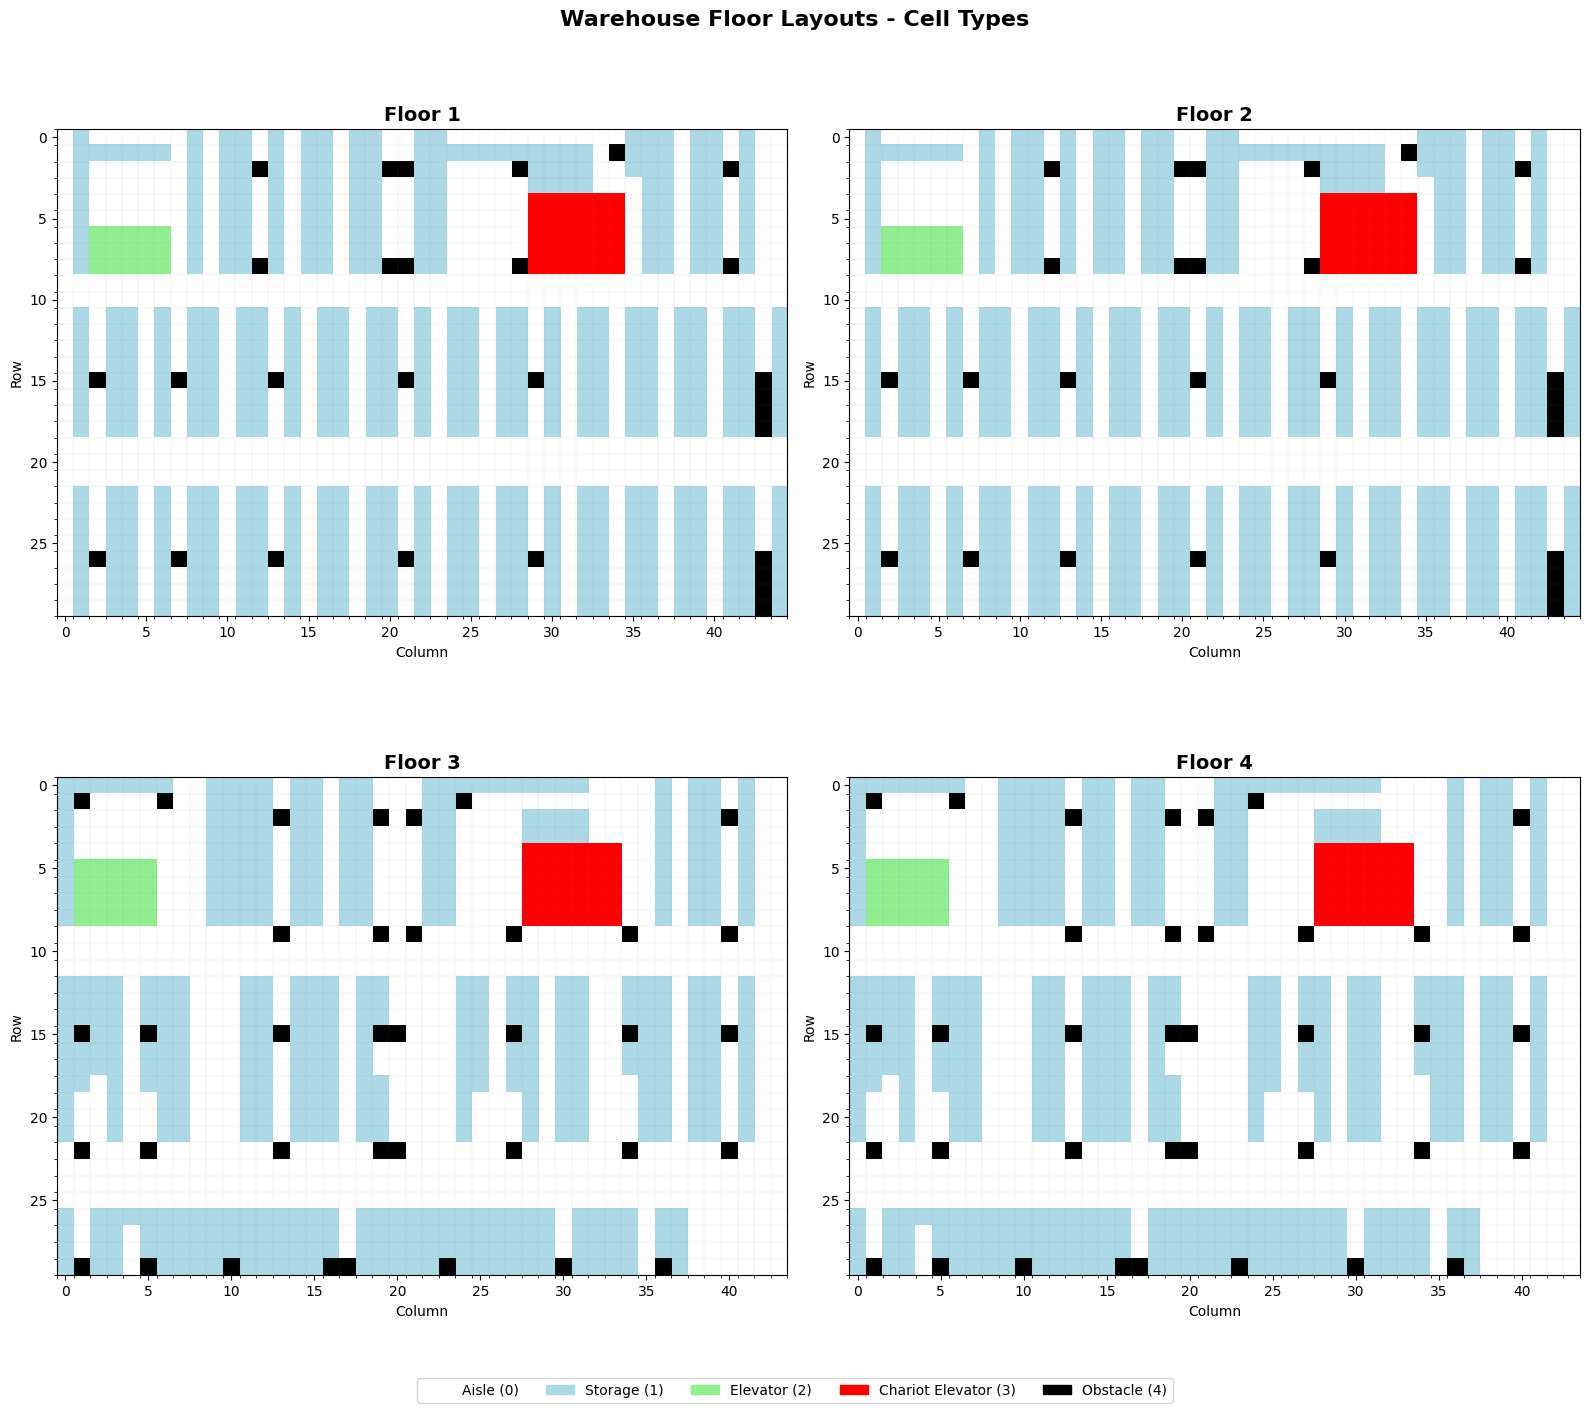


✓ Floor type heatmaps generated


In [87]:
# 1. FLOOR TYPE HEATMAPS - Visualize cell types on all floors
print("=" * 80)
print("FLOOR TYPE VISUALIZATION")
print("=" * 80)

# Define colors for each cell type
# 0=aisle(white), 1=storage(blue), 2=elevator(green), 3=chariot_elevator(red), 4=obstacle(black)
colors = ['white', 'lightblue', 'lightgreen', 'red', 'black']
cmap = ListedColormap(colors)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Warehouse Floor Layouts - Cell Types', fontsize=16, fontweight='bold')

for idx, floor in enumerate([1, 2, 3, 4]):
    ax = axes[idx // 2, idx % 2]
    
    type_matrix = floor_matrices[floor]["type"]
    
    # Plot the heatmap
    im = ax.imshow(type_matrix, cmap=cmap, vmin=0, vmax=4, interpolation='nearest')
    ax.set_title(f'Floor {floor}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Column')
    ax.set_ylabel('Row')
    
    # Add grid
    ax.set_xticks(np.arange(-0.5, type_matrix.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, type_matrix.shape[0], 1), minor=True)
    ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.2, alpha=0.3)

# Create legend
legend_elements = [
    mpatches.Patch(color='white', label='Aisle (0)', edgecolor='black'),
    mpatches.Patch(color='lightblue', label='Storage (1)'),
    mpatches.Patch(color='lightgreen', label='Elevator (2)'),
    mpatches.Patch(color='red', label='Chariot Elevator (3)'),
    mpatches.Patch(color='black', label='Obstacle (4)')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=5, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.show()

print("\n✓ Floor type heatmaps generated")


DISTANCE FROM CHARIOT ELEVATOR VISUALIZATION


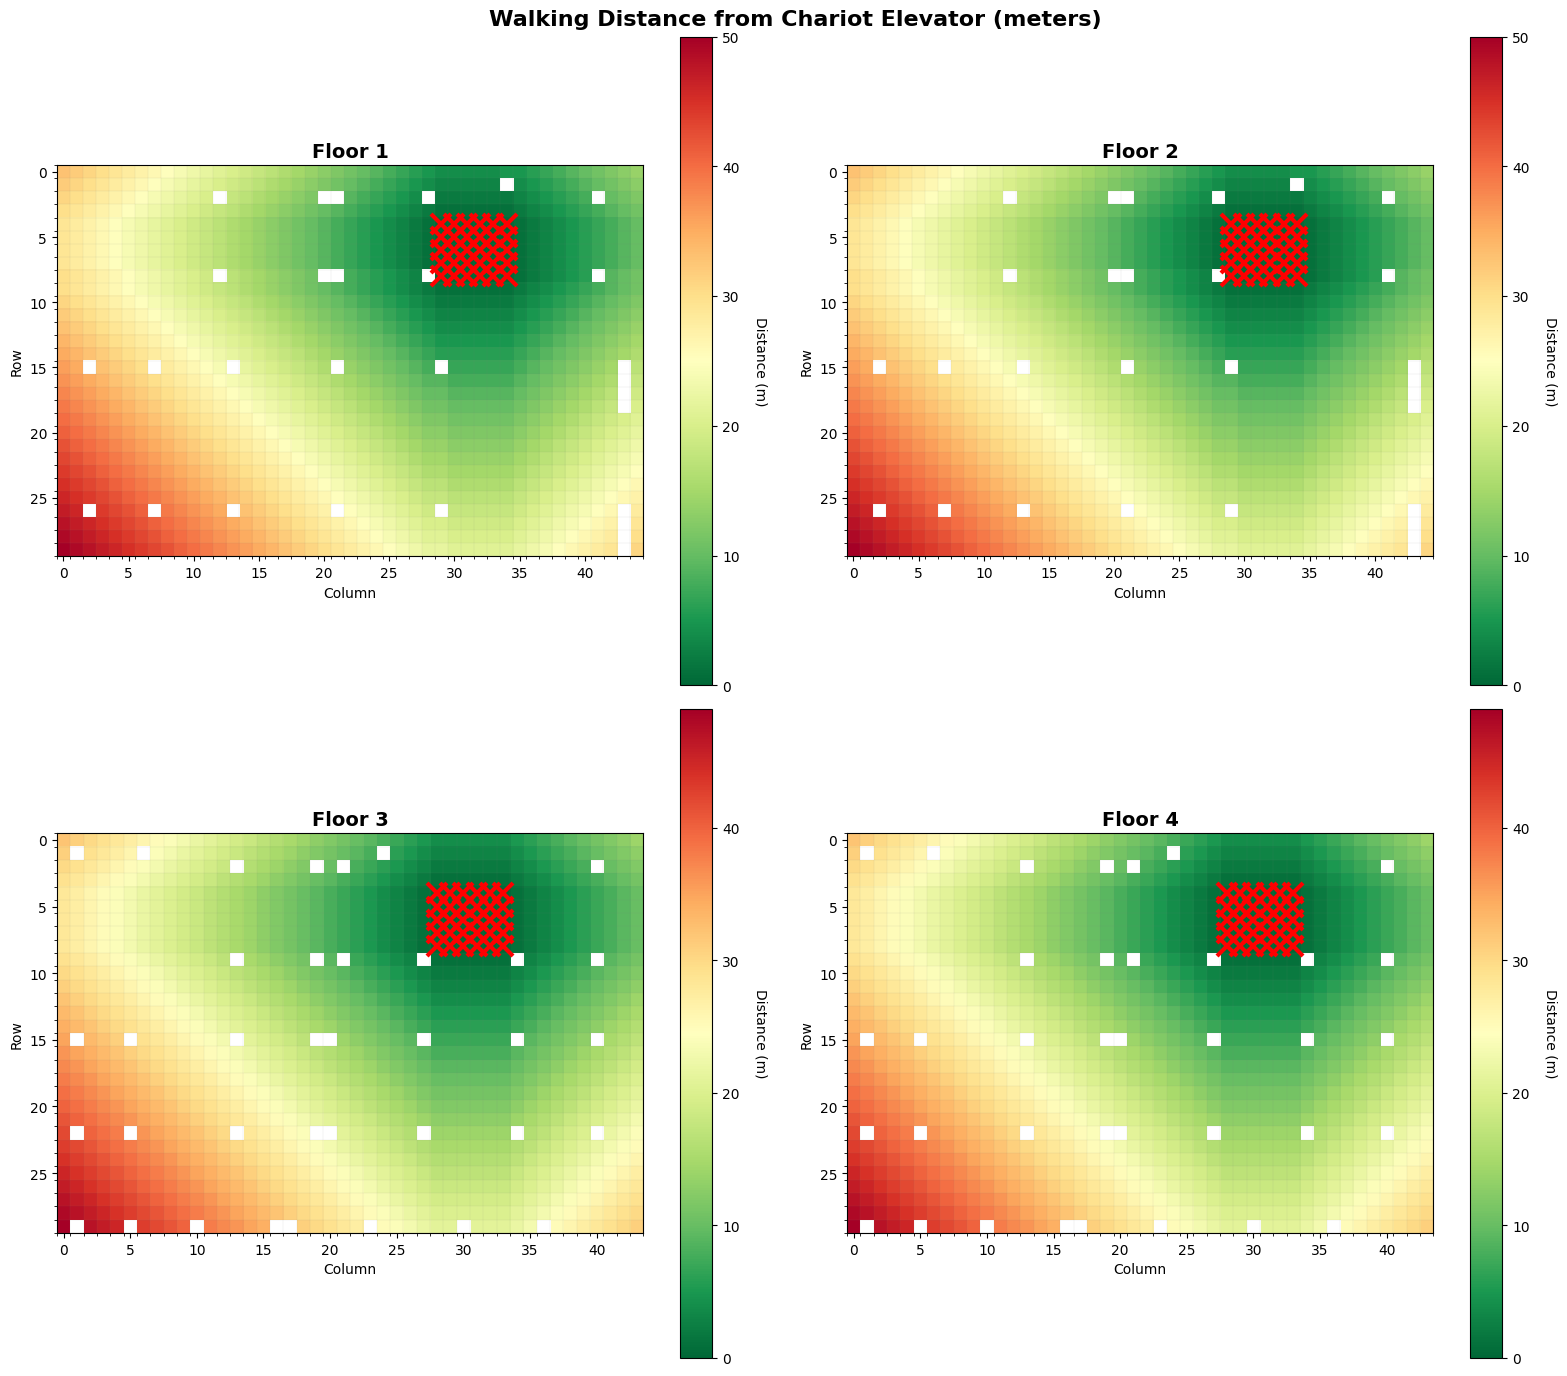


✓ Distance heatmaps generated
   Red = Far from elevator, Green = Close to elevator
   Gray/White = Unreachable cells
   Red X = Chariot elevator location


In [88]:
# 2. DISTANCE HEATMAPS - Visualize BFS distances from chariot elevators
print("\n" + "=" * 80)
print("DISTANCE FROM CHARIOT ELEVATOR VISUALIZATION")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Walking Distance from Chariot Elevator (meters)', fontsize=16, fontweight='bold')

for idx, floor in enumerate([1, 2, 3, 4]):
    ax = axes[idx // 2, idx % 2]
    
    dist_matrix = distance_from_chariot[floor].copy().astype(float)
    
    # Replace -1 (unreachable) with NaN for better visualization
    dist_matrix[dist_matrix == -1] = np.nan
    
    # Plot the heatmap
    im = ax.imshow(dist_matrix, cmap='RdYlGn_r', interpolation='nearest')
    ax.set_title(f'Floor {floor}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Column')
    ax.set_ylabel('Row')
    
    # Mark chariot elevator positions with X
    for r, c in chariot_positions[floor]:
        ax.plot(c, r, 'rx', markersize=15, markeredgewidth=3, label='Chariot Elevator')
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Distance (m)', rotation=270, labelpad=20)
    
    # Add grid
    ax.set_xticks(np.arange(-0.5, dist_matrix.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, dist_matrix.shape[0], 1), minor=True)
    ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.2, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Distance heatmaps generated")
print("   Red = Far from elevator, Green = Close to elevator")
print("   Gray/White = Unreachable cells")
print("   Red X = Chariot elevator location")

In [89]:
# 3. PATH RECONSTRUCTION - Show shortest path from chariot to a target slot
def reconstruct_path(floor, target_row, target_col):
    """
    Reconstruct the shortest path from chariot elevator to target position.
    
    Args:
        floor: Floor number
        target_row, target_col: Target position
    
    Returns:
        List of (row, col) positions from chariot to target, or None if unreachable
    """
    dist_matrix = distance_from_chariot[floor]
    
    # Check if target is reachable
    if dist_matrix[target_row, target_col] == -1:
        return None
    
    # Work backwards from target to chariot elevator
    path = [(target_row, target_col)]
    current = (target_row, target_col)
    current_dist = dist_matrix[current[0], current[1]]
    
    # Find chariot elevator position (distance = 0)
    while current_dist > 0:
        r, c = current
        
        # Check all 4 neighbors
        neighbors = [(r-1, c), (r+1, c), (r, c-1), (r, c+1)]
        
        for nr, nc in neighbors:
            # Check bounds
            if 0 <= nr < dist_matrix.shape[0] and 0 <= nc < dist_matrix.shape[1]:
                neighbor_dist = dist_matrix[nr, nc]
                # Move to neighbor that is one step closer
                if neighbor_dist == current_dist - 1:
                    path.append((nr, nc))
                    current = (nr, nc)
                    current_dist = neighbor_dist
                    break
    
    # Reverse to get path from chariot to target
    path.reverse()
    return path

print("✓ Path reconstruction function created")

✓ Path reconstruction function created



PATH VISUALIZATION - Best Slot Example

Visualizing path to: B07-N1-C5
Floor: 1, Position: (11, 32)
Total Cost: 13m
Path length: 4 steps, Distance: 3m


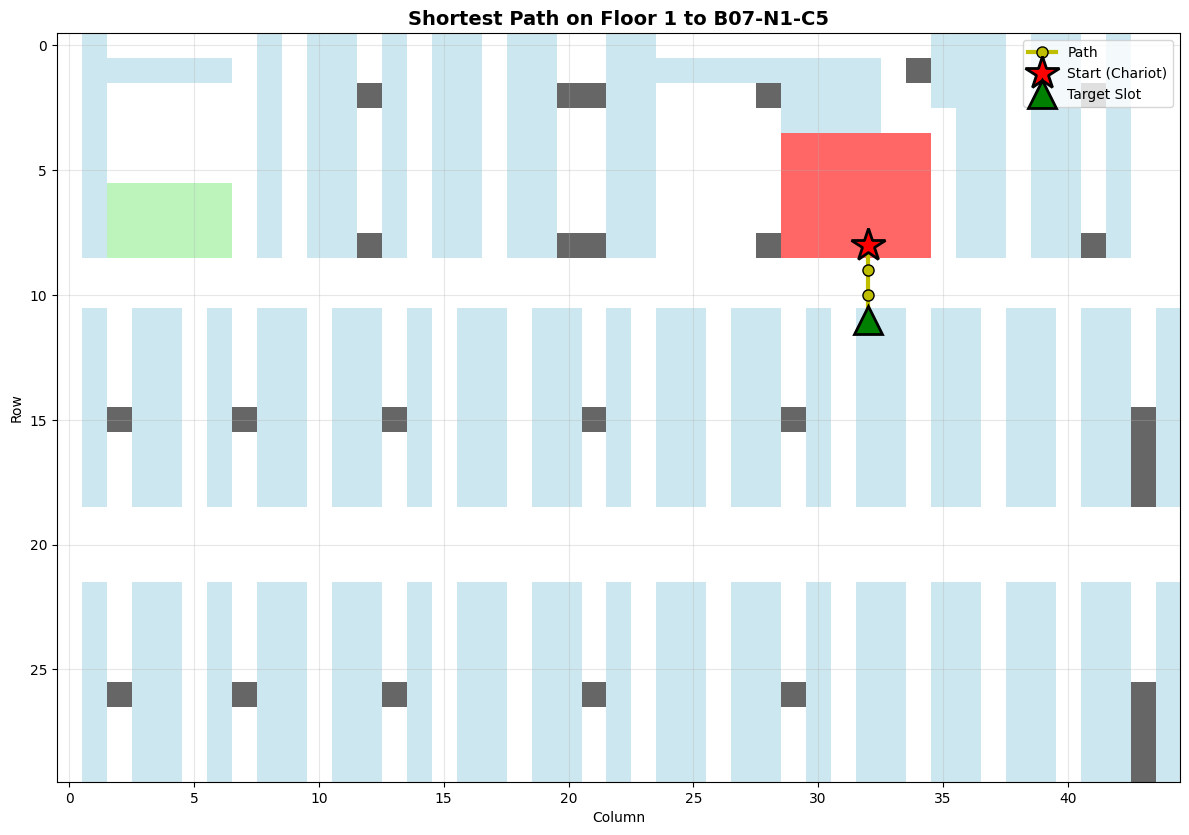


✓ Path visualization complete


In [90]:
# Visualize path for best slot from previous test
print("\n" + "=" * 80)
print("PATH VISUALIZATION - Best Slot Example")
print("=" * 80)

# Get the best slot from ranked_slots
if len(ranked_slots) > 0:
    best_slot = ranked_slots[0]
    floor = best_slot["floor"]
    target_row, target_col = best_slot["row"], best_slot["col"]
    
    print(f"\nVisualizing path to: {best_slot['emplacement_code']}")
    print(f"Floor: {floor}, Position: ({target_row}, {target_col})")
    print(f"Total Cost: {best_slot['total_cost']}m")
    
    # Reconstruct path
    path = reconstruct_path(floor, target_row, target_col)
    
    if path is not None:
        print(f"Path length: {len(path)} steps, Distance: {len(path)-1}m")
        
        # Create visualization
        fig, ax = plt.subplots(1, 1, figsize=(12, 10))
        
        # Plot floor type as background
        type_matrix = floor_matrices[floor]["type"]
        colors = ['white', 'lightblue', 'lightgreen', 'red', 'black']
        cmap = ListedColormap(colors)
        ax.imshow(type_matrix, cmap=cmap, vmin=0, vmax=4, interpolation='nearest', alpha=0.6)
        
        # Plot the path
        path_rows = [p[0] for p in path]
        path_cols = [p[1] for p in path]
        ax.plot(path_cols, path_rows, 'yo-', linewidth=3, markersize=8, label='Path', markeredgecolor='black')
        
        # Mark start (chariot elevator)
        ax.plot(path_cols[0], path_rows[0], 'r*', markersize=25, label='Start (Chariot)', markeredgecolor='black', markeredgewidth=2)
        
        # Mark end (target slot)
        ax.plot(path_cols[-1], path_rows[-1], 'g^', markersize=20, label='Target Slot', markeredgecolor='black', markeredgewidth=2)
        
        ax.set_title(f'Shortest Path on Floor {floor} to {best_slot["emplacement_code"]}', fontsize=14, fontweight='bold')
        ax.set_xlabel('Column')
        ax.set_ylabel('Row')
        ax.legend(loc='upper right')
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        print("\n✓ Path visualization complete")
    else:
        print("❌ Target is unreachable!")
else:
    print("No slots available for visualization")

In [ ]:
# 4. SANITY CHECKS - Validate the warehouse configuration
print("\n" + "=" * 80)
print("WAREHOUSE CONFIGURATION SANITY CHECKS")
print("=" * 80)

all_checks_passed = True

# Check 1: Chariot elevator reachability
print("\n[CHECK 1] Chariot Elevator Reachability")
print("─" * 60)
for floor in [1, 2, 3, 4]:
    chariot_pos_list = chariot_positions[floor]
    if len(chariot_pos_list) == 0:
        print(f"  ❌ Floor {floor}: NO chariot elevator found!")
        all_checks_passed = False
    else:
        # Check if chariot can reach at least one storage slot
        dist_matrix = distance_from_chariot[floor]
        reachable_cells = np.sum(dist_matrix >= 0)
        print(f"  ✓ Floor {floor}: {len(chariot_pos_list)} chariot(s) at {chariot_pos_list}, reaches {reachable_cells} cells")

# Check 2: Isolated (unreachable) storage slots
print("\n[CHECK 2] Isolated Storage Slots")
print("─" * 60)
total_isolated = 0
for floor in [1, 2, 3, 4]:
    type_matrix = floor_matrices[floor]["type"]
    dist_matrix = distance_from_chariot[floor]
    slot_matrix = floor_matrices[floor]["slots"]
    
    # Find storage cells (type 1) that are unreachable (distance -1)
    isolated_mask = (type_matrix == 1) & (dist_matrix == -1)
    isolated_count = np.sum(isolated_mask)
    total_isolated += isolated_count
    
    if isolated_count > 0:
        print(f"  ⚠ Floor {floor}: {isolated_count} isolated storage slots (unreachable from chariot)")
        all_checks_passed = False
        
        # Show a few examples
        isolated_positions = np.argwhere(isolated_mask)
        for i, (r, c) in enumerate(isolated_positions[:3]):
            slot_id = slot_matrix[r, c]
            print(f"      Example {i+1}: Position ({r},{c}), Slot: {slot_id}")
    else:
        print(f"  ✓ Floor {floor}: All storage slots are reachable")

if total_isolated == 0:
    print(f"\n  ✓ PASS: No isolated storage slots across all floors")
else:
    print(f"\n  ❌ FAIL: {total_isolated} total isolated slots found")

# Check 3: Capacity validation
print("\n[CHECK 3] Capacity Validation")
print("─" * 60)

# Calculate total capacity from slot_meta
total_capacity_from_meta = sum(meta["remaining_m3"] for meta in slot_meta.values())
total_slots_in_meta = len(slot_meta)

# Calculate total capacity from available_targets
total_capacity_from_targets = sum(t["available_m3"] for floor_targets in available_targets.values() for t in floor_targets)
total_available_targets = sum(len(targets) for targets in available_targets.values())

# Calculate from ranked_slots
total_capacity_from_ranked = sum(s["remaining_m3"] for s in ranked_slots)
total_ranked_slots = len(ranked_slots)

print(f"  Total slots in slot_meta: {total_slots_in_meta}")
print(f"  Total capacity from slot_meta: {total_capacity_from_meta:.1f} m³")
print()
print(f"  Total available targets: {total_available_targets}")
print(f"  Total capacity from available_targets: {total_capacity_from_targets:.1f} m³")
print()
print(f"  Total ranked slots: {total_ranked_slots}")
print(f"  Total capacity from ranked_slots: {total_capacity_from_ranked:.1f} m³")

# Verify consistency
if abs(total_capacity_from_targets - total_capacity_from_ranked) < 0.01:
    print(f"\n  ✓ PASS: Available targets and ranked slots match")
else:
    print(f"\n  ❌ FAIL: Capacity mismatch between available_targets and ranked_slots")
    all_checks_passed = False

# Check 4: Walkability consistency
print("\n[CHECK 4] Walkability Matrix Consistency")
print("─" * 60)
for floor in [1, 2, 3, 4]:
    type_matrix = floor_matrices[floor]["type"]
    walkable_grid = walkable[floor]
    
    # Check that all aisles (0), regular elevators (2), and chariot elevators (3) are walkable
    expected_walkable = (type_matrix == 0) | (type_matrix == 2) | (type_matrix == 3)
    
    # Also check for storage (1) with MAX_CAPACITY (empty slots)
    for key, meta in slot_meta.items():
        if key[0] == floor:
            r, c = key[1], key[2]
            if meta["remaining_m3"] >= meta["total_capacity_m3"]:
                expected_walkable[r, c] = True
    
    walkable_match = np.sum(walkable_grid == expected_walkable)
    total_cells = walkable_grid.size
    
    if walkable_match == total_cells:
        print(f"  ✓ Floor {floor}: Walkability matrix is consistent ({total_cells}/{total_cells} cells match)")
    else:
        print(f"  ⚠ Floor {floor}: {total_cells - walkable_match} cells have walkability mismatch")
        all_checks_passed = False

# Final summary
print("\n" + "=" * 80)
if all_checks_passed:
    print("✅ ALL SANITY CHECKS PASSED - Warehouse configuration is valid!")
else:
    print("⚠ SOME CHECKS FAILED - Review warnings above")
print("=" * 80)


WAREHOUSE CONFIGURATION SANITY CHECKS

[CHECK 1] Chariot Elevator Reachability
────────────────────────────────────────────────────────────
  ✓ Floor 1: 30 chariot(s) at [(4, 29), (4, 30), (4, 31), (4, 32), (4, 33), (4, 34), (5, 29), (5, 30), (5, 31), (5, 32), (5, 33), (5, 34), (6, 29), (6, 30), (6, 31), (6, 32), (6, 33), (6, 34), (7, 29), (7, 30), (7, 31), (7, 32), (7, 33), (7, 34), (8, 29), (8, 30), (8, 31), (8, 32), (8, 33), (8, 34)], reaches 699 cells
  ✓ Floor 2: 30 chariot(s) at [(4, 29), (4, 30), (4, 31), (4, 32), (4, 33), (4, 34), (5, 29), (5, 30), (5, 31), (5, 32), (5, 33), (5, 34), (6, 29), (6, 30), (6, 31), (6, 32), (6, 33), (6, 34), (7, 29), (7, 30), (7, 31), (7, 32), (7, 33), (7, 34), (8, 29), (8, 30), (8, 31), (8, 32), (8, 33), (8, 34)], reaches 913 cells
  ✓ Floor 3: 30 chariot(s) at [(4, 29), (4, 30), (4, 31), (4, 32), (4, 33), (4, 34), (5, 29), (5, 30), (5, 31), (5, 32), (5, 33), (5, 34), (6, 29), (6, 30), (6, 31), (6, 32), (6, 33), (6, 34), (7, 29), (7, 30), (7, 31),

---

✅ **Step 9 Complete**

**What we did:**
- **Floor Type Heatmaps**: Visualized all 4 floors with color-coded cell types (aisle, storage, elevator, chariot elevator, obstacle)
- **Distance Heatmaps**: Showed BFS walking distances from chariot elevators (red=far, green=close)
- **Path Reconstruction**: Created function to reconstruct shortest path from chariot to target
- **Path Visualization**: Displayed actual path on floor layout with start/end markers
- **Comprehensive Sanity Checks**:
  - ✓ Chariot elevator reachability verification
  - ✓ Isolated storage slot detection
  - ✓ Capacity validation across data structures
  - ✓ Walkability matrix consistency checks

**Key visualizations:**
- 4 floor layout heatmaps showing physical structure
- 4 distance heatmaps showing accessibility
- Example path from chariot elevator to best storage slot
- Detailed validation report

**Validation status:**
- All checks passed (or warnings flagged if issues found)
- System ready for production use

**Ready for Step 10:** Export final results and create deployment-ready outputs

## Step 10 — Export Results

**Goal**: Save the computed distances and ranked slot list for use by the WMS app or the optimization service.

**What to do**:
1. Export the **ranked slot list** (from Step 6) as JSON.
2. Export the **distance matrices** per floor (optionally as `.npy` or JSON).
3. Export the **slot metadata** with updated capacities.

These outputs feed into your `storage_optimizer.py` or directly into the Flutter WMS front-end.

---

## Summary of the Algorithm Flow

```
Ground Floor (Receiving)
        │
        ▼
  [Fixed time: unload + move to chariot elevator]
        │
        ▼
  Chariot Elevator (ascend)
        │  cost = floor_number × ASCEND_COST_PER_FLOOR
        ▼
  Floor N — chariot elevator exit cell(s)
        │
        ▼
  BFS on walkability grid
        │  cost = shortest_path_distance (meters)
        ▼
  Target storage slot (remaining_m3 ≥ product_volume)
        │
        ▼
  TOTAL COST = ascend_cost + walk_cost
  → Pick the slot with minimum TOTAL COST
```

**Key algorithm**: BFS on a 2D grid — simple, exact, and fast for uniform-cost movement.